# Preparation

### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import os
from matplotlib.ticker import FormatStrFormatter
import itertools as it
from copy import deepcopy

### Exp

In [2]:
def flatten_dict(d, parent_key='', sep='.'):
    items = []
    for k, v in d.items():
        new_key = parent_key + sep + k if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

def read_json(file_path):
    with open(file_path, 'r') as json_file:
        data = json.load(json_file)
    return data

In [3]:
def load_all_configurations(exp_name:str='prova', folder_name:str= '../out/exp/'):
    experiments = {}
    for single_config in os.listdir(os.path.join(os.getcwd(),folder_name,exp_name)):
        exp_id = single_config.replace('.json', '')
        data = read_json(os.path.join(os.getcwd(),folder_name,exp_name,single_config))
        experiments[exp_id] = flatten_dict(data)
    return pd.DataFrame.from_dict(dict(sorted(experiments.items())), "index") #sorted is not actually needed

In [4]:
def load_metrics(exp_name:str='prova', folder_name:str= '../out/log/'):
    results = {}
    exp_log_folder = os.path.join(os.getcwd(),folder_name,exp_name)
    for exp_id in os.listdir(exp_log_folder):
        metrics_filepath = os.path.join(exp_log_folder,exp_id,'lightning_logs/version_0/metrics.csv')
        data = pd.read_csv(metrics_filepath)
        results[exp_id] = data
    return dict(sorted(results.items()))

In [5]:
def get_metrics_given_best_val(metrics_per_epoch, metrics_names, metrics_prefix = "val", metrics_dataloader_idx=1, val_prefix = "val", val_metric="NDCG@10", val_dataloader_idx=0, fix_rec_at_k=False):
    if fix_rec_at_k:
        val_metric =val_metric.replace('@','_@')
        metrics_names = [metric.replace('@','_@') for metric in metrics_names]
    val_key = f"{val_prefix}_{val_metric}"
    if val_dataloader_idx is not None:
        val_key += f"/dataloader_idx_{val_dataloader_idx}"
    metric_keys = [f"{metrics_prefix}_{metric}" for metric in metrics_names]
    if metrics_dataloader_idx is not None:
        metric_keys = [f"{metric}/dataloader_idx_{metrics_dataloader_idx}" for metric in metric_keys]
    best_metrics = {}
    for exp_id, metrics in metrics_per_epoch.items():
        best_val_row = metrics[val_key].argmax()
        best_metrics[exp_id] = {metric_name: metrics[metric_key][best_val_row] for metric_name, metric_key in zip(metrics_names,metric_keys) if metric_key in metrics}
    return pd.DataFrame.from_dict(dict(sorted(best_metrics.items())), "index") #sorted is not actually needed

In [6]:
def hotfix_table(table, col, value=0.5):
    for exp_id in table.index.get_level_values(0).unique():
        exp_loc = table.index.get_level_values(0) == exp_id
        vals = table.loc[exp_loc][col][1:-1].values
        mean_vals = (table.loc[exp_loc][col][:-2].values+table.loc[exp_loc][col][2:].values)/2
        over_threshold = np.abs(vals-mean_vals)>value
        sel_app = exp_loc
        app = np.concatenate((np.array([False]),over_threshold,np.array([False])))
        sel_app[sel_app] = app
        table.loc[sel_app,col] = mean_vals[over_threshold]
    return table

In [ ]:
columns_for_diffs = ['duration', 'emissions', 'emissions_rate', 'cpu_power', 'gpu_power',
                    'ram_power', 'cpu_energy', 'gpu_energy', 'ram_energy',
                    'energy_consumed']
columns_that_are_same = ['project_name', 'run_id', 'country_name',
    'country_iso_code', 'region', 'cloud_provider', 'cloud_region', 'os',
    'python_version', 'codecarbon_version', 'cpu_count', 'cpu_model',
    'gpu_count', 'gpu_model', 'longitude', 'latitude', 'ram_total_size',
    'tracking_mode', 'on_cloud', 'pue']
columns_that_are_different = ['timestamp']

def load_emissions(exp_name:str='prova', folder_name:str= '../out/log/', splits = ['train', 'test']):
    emissions = {}
    exp_log_folder = os.path.join(os.getcwd(),folder_name,exp_name)
    for exp_id in os.listdir(exp_log_folder):
        emissions_filepath = os.path.join(exp_log_folder,exp_id,'emissions.csv')
        if not os.path.exists(emissions_filepath): continue
        data = pd.read_csv(emissions_filepath)
    
        new_data = {}
        for column in columns_for_diffs:
            for i,split in enumerate(splits):
                new_data[f"{split}_{column}"] = data.iloc[i][column]
                if i > 0:
                    new_data[f"{split}_diff_{column}"] = data.iloc[i][column] - data.iloc[i-1][column]
            # new_data[f"train_{column}"] = data.iloc[0][column]
            # new_data[f"test_{column}"] = data.iloc[1][column] - data.iloc[0][column]
        for column in columns_that_are_same:
            new_data[f"{column}"] = data.iloc[0][column]
        for column in columns_that_are_different:
            for i,split in enumerate(splits):
                new_data[f"{split}_{column}"] = data.iloc[i][column]
        emissions[exp_id] = new_data

    return pd.DataFrame.from_dict(dict(sorted(emissions.items())), "index") #sorted is not actually needed

In [8]:
modifiers = {"":1, "K":1e3, "M":1e6, "G":1e9, "T":1e12, "P":1e15}
strings_to_search = {"num_params":"params per GPU:",
                     "flops": "fwd flops per GPU:",
                     "latency": "fwd latency:",
                     "FLOPS": "fwd FLOPS per GPU = fwd flops per GPU / fwd latency:"}

def extract_flops_info(complete_string, string_to_search):
    if string_to_search in complete_string:
        value = complete_string.split(string_to_search)[1].split("\n")[0].strip()
    else: value = "nan"
    measure = ""
    if " " in value: value, measure = value.split(" ")
    scale = measure[0] if len(measure)>0 else ""
    if scale not in modifiers:
        scale = ""
        measure = " " + measure
    unit = "" if len(measure)==1 else measure[1:]
    return float(value)*modifiers[scale], unit

def load_flops(exp_name:str='prova', folder_name:str= '../out/log/', split_keys = ["train", "test"]):
    flops = {}
    exp_log_folder = os.path.join(os.getcwd(),folder_name,exp_name)
    for exp_id in os.listdir(exp_log_folder):
        new_data = {}
        for split_key in split_keys:
            flops_filepath = os.path.join(exp_log_folder,exp_id,f'{split_key}_flops.txt')
            if not os.path.exists(flops_filepath): continue
            #load flops_filepath txt
            with open(flops_filepath, 'r') as file:
                data = file.read()
            
            for measure_name,string_to_search in strings_to_search.items():
                value, unit = extract_flops_info(data, string_to_search)
                measure_key = f"{split_key}_{measure_name}"
                #if unit != "": measure_key += f" ({unit})"
                new_data[measure_key] = value
            
        flops[exp_id] = new_data

    return pd.DataFrame.from_dict(dict(sorted(flops.items())), "index") #sorted is not actually needed

In [9]:
## Add emissions and flops info to metrics_per_epoch
def add_info_single_df(df, exp_data, subset_col, split_name, column_labels):
    if subset_col not in df.columns:
        split_subset = np.zeros(len(df), dtype=bool)
        split_subset[-1] = True
    else:
        split_subset = ~df[subset_col].isna()
    num_split = sum(split_subset)
    for label in column_labels:
        split_label = f"{split_name}_{label}"
        df.loc[split_subset,split_label] = np.linspace(exp_data[split_label]/num_split,exp_data[split_label],num_split)
    

def add_info_to_metrics_per_epoch(metrics_per_epoch, complete_data, column_labels, split_names = ["train", "test"], repeat_for = ["val_loss/dataloader_idx_0",None]):
    for exp_id,df in metrics_per_epoch.items():
        for split_name,repeat_col in zip(split_names,repeat_for):
            add_info_single_df(df, complete_data.loc[exp_id], f"{split_name}_loss", split_name, column_labels)
            if repeat_col is not None:
                add_info_single_df(df, complete_data.loc[exp_id], repeat_col, split_name, column_labels)
        metrics_per_epoch[exp_id] = df

### Table utils

In [10]:
def subset_data(complete_data, subset_selection={}, subset_keep=[], merge_columns={}):
    subset_data = complete_data
    for label, value in subset_selection.items():
        subset_data = subset_data[subset_data[label] == value]

    for condition1, condition2 in subset_keep:
        for label, value in condition1.items():
            subset_data2 = subset_data[subset_data[label] == value]
        indices = subset_data2.index
        for label, value in condition2.items():
            subset_data2 = subset_data2[subset_data2[label] == value]
        indices2 = subset_data2.index
        #remove for subset_data idx not in indices2
        indices_to_remove = [idx for idx in indices if idx not in indices2]
        subset_data = subset_data.drop(indices_to_remove)
        
    for col_name, cols in merge_columns.items():
        subset_data[col_name] = subset_data.loc[:,cols].apply(lambda row: '_'.join([str(x) for x in row if pd.notnull(x)]), axis=1)
        subset_data = subset_data.drop(columns=cols)
    
    return subset_data

def generate_table(subset_data,
                   rows_labels, column_labels,
                   pivot_agg = lambda x: x,
                   table_name="results", save_table=False, round_at=4,
                   exp_name:str='prova', folder_name:str= '../out/results/'):

    subset_data = subset_data[rows_labels + column_labels]

    table = pd.pivot_table(subset_data, index=rows_labels, values=column_labels, dropna=False, aggfunc=pivot_agg)

    # Drop if all column_labels are nans
    drop_row = table[column_labels].isnull().all(axis=1)
    table = table[~drop_row]

    table.reset_index(inplace=True)


    table = table.round(round_at)

    if save_table:
        results_path = os.path.join(folder_name,exp_name)
        if not os.path.exists(results_path):
            os.makedirs(results_path)
        table.to_csv(os.path.join(results_path,f'{table_name}.csv'), index=False)
    return table

### Plot utils

In [11]:
def to_color_blind(color):
    if color == 'red':
        return '#e41a1c'
    elif color == 'blue':
        return '#377eb8'
    elif color == 'orange':
        return '#ff7f00'
    elif color == 'green':
        return '#4daf4a'
    elif color == 'brown':
        return '#a65628'
    elif color == 'grey':
        return '#999999'
    elif color == 'yellow':
        return '#dede00'
    elif color == 'pink':
        return '#f781bf'
    elif color == 'purple':
        return '#984ea3'
    else:
        raise NotImplementedError("color not available")

def obtain_markers(number_of_markers):
    list_of_markers = ['o', 'v', 's', 'p', 'P', '*', 'X', '+', 'D', 'x']
    return list_of_markers[:number_of_markers]

def obtain_color(number_of_colors):
    all = ['#e41a1c', '#377eb8','#ff7f00','#4daf4a','#a65628',
        '#999999','#dede00','#f781bf','#984ea3']
    return all[:number_of_colors]

In [12]:
def create_plot(plot_instructions,
                **kwargs):
    final_fig, final_ax = plt.subplots(**plot_instructions["subplots"])
    
    # If final_ax is iterable
    if hasattr(final_ax, '__iter__'):
        for i,ax in enumerate(final_ax.flatten()):
            single_plot(ax, **{k:v[i] if isinstance(v, list) or isinstance(v, tuple) else v for k,v in kwargs.items()})
    else:
        single_plot(final_ax, **kwargs)

    for plt_func, plt_kwargs in plot_instructions.items():
        if plt_func != "subplots":
            run_plot_func(plt, plt_func, plt_kwargs)

def single_plot(ax,
                data,
                label_columns: list,
                x_column: str,
                y_column: str,
                plot_type = "plot",
                plot_kwargs = {},
                ax_instructions: dict = {},
                label_convert_dict: dict = {}):
    labels = []
    for col in label_columns:
        labels.append(data[col].unique())
    labels = list(it.product(*labels))
    plot_labels = [x[0] if len(x) == 1 else x for x in labels]
    plot_labels = [label_convert_dict.get(x, x) for x in plot_labels]
    labels = [x[1] for x in sorted(zip(plot_labels,labels))]
    plot_labels = sorted(plot_labels)

    colors = obtain_color(len(labels))
    markers = obtain_markers(len(labels))
        
    for i, values in enumerate(labels):
        subset_data = data
        for col, value in zip(label_columns, values):
            subset_data = subset_data[subset_data[col] == value]
        
        x_values = subset_data[x_column]
        y_values = subset_data[y_column]
        getattr(ax,plot_type)(x_values, y_values, label=plot_labels[i], color=colors[i], marker=markers[i], **plot_kwargs)
    
    for ax_func, ax_kwargs in ax_instructions.items():
        run_plot_func(ax, ax_func, ax_kwargs.copy())

def run_plot_func(obj, func, kwargs):
    other_func_instructions = None
    if "__kwargs__" in kwargs:
        func_kwargs = kwargs.pop("__kwargs__")
        kwargs, other_func_instructions = func_kwargs, kwargs
    
    app = getattr(obj, func)(**kwargs)
    if other_func_instructions is not None:
        for func, kwargs in other_func_instructions.items():
            run_plot_func(app, func, kwargs)
    
    # for index, (model, data) in enumerate(results.items()):
    #     ablation_values = list(data.keys())
    #     y_values = list(data.values())
    #     plt.plot(ablation_values, y_values, label=model, color=colors[index], marker=markers[index])
    # 
    # plt.xticks(ablation_values, ablation_values)
    # plt.xlabel(names_to_labels[ablation_type])
    # plt.ylabel(metric)
    # plt.title(names_to_labels[dataset_name])
    # plt.legend()
    # plt.show()

In [13]:
def merge_epoch_data(metrics_per_epoch, table, table_columns = [], epoch_column_not_na = "val_loss/dataloader_idx_1"):
    subset_metrics = {}
    for exp_id in table.index:
        subset_metrics[exp_id] = metrics_per_epoch[exp_id]
    
        subset_metrics[exp_id] = subset_metrics[exp_id].loc[~subset_metrics[exp_id][epoch_column_not_na].isna()]
        
        for col in table_columns:
            subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
    
    #concat all dataframes by row
    subset_metrics = pd.concat(subset_metrics)
    
    return subset_metrics

### Important vars

In [14]:
names_to_labels = {'ml-1m' : 'MovieLens 1M', 'ml-100k' : 'MovieLens 100k', 'amazon_beauty' : 'Amazon Beauty', 'foursquare-tky' : 'Foursquare TKY', 'foursquare-nyc' : 'Foursquare NYC',
                   'emb_size' : 'Embedding Size', 'lookback' : 'Input sequence length', 'carbon_emissions' : r'CO\textsubscript{2}-eq', 'model_size' : 'Model Size',
                   'ml-20m': 'MovieLens 20M'}

In [15]:
all_datasets = sorted(['ml-1m', 'ml-100k', 'amazon_beauty', 'foursquare-tky', 'foursquare-nyc'])
all_models= sorted(['SASRec','NARM', 'GRU4Rec', 'BERT4Rec', 'CORE'])
metrics_names = ["Precision", "Recall", "NDCG", "MAP"]
metrics_ks = [5, 10, 20]
all_metrics_names = [f"{metric}@{k}" for metric in metrics_names for k in metrics_ks]

# MAIN

## Load all experiments

### Exp configs

In [16]:
exp_name = "May_8"

In [17]:
all_exps = load_all_configurations(exp_name)

In [18]:
all_exps

,data_params.collator_params.lookback,data_params.collator_params.lookforward,data_params.collator_params.num_items,data_params.collator_params.num_negatives.test,data_params.collator_params.num_negatives.train,data_params.collator_params.num_negatives.val,data_params.collator_params.out_seq_len.test,data_params.collator_params.out_seq_len.train,data_params.collator_params.out_seq_len.val,data_params.collator_params.padding_value,...,model.rec_model.lookback,model.rec_model.name,model.rec_model.num_items,model.rec_model.num_layers,model.rec_model.num_users,model.trainer_params.callbacks,model.trainer_params.max_epochs,model.rec_model.dropout_rate,model.rec_model.num_blocks,model.rec_model.num_heads
02aTlr7kC6tzuSqW,200,1,1076,100,2,1,1,None,1,0,...,200,GRU4Rec,1076,1.0,1274,"[{'ModelCheckpoint': {'mode': 'min', 'monitor'...",600,NaN,NaN,NaN
0kNAmyh9al6qgGzB,200,1,15177,100,50,1,1,None,1,0,...,200,SASRec,15177,NaN,2293,"[{'ModelCheckpoint': {'mode': 'min', 'monitor'...",600,0.2,1.0,1.0
0migpgTG4avYEDXM,200,1,1076,100,20,1,1,None,1,0,...,200,GRU4Rec,1076,1.0,1274,"[{'ModelCheckpoint': {'mode': 'min', 'monitor'...",600,NaN,NaN,NaN
1uOEvgHZNXteuPNU,200,1,15177,100,3,1,1,None,1,0,...,200,GRU4Rec,15177,1.0,2293,"[{'ModelCheckpoint': {'mode': 'min', 'monitor'...",600,NaN,NaN,NaN
2598HEdcojn1KuoB,200,1,1076,100,10,1,1,None,1,0,...,200,GRU4Rec,1076,1.0,1274,"[{'ModelCheckpoint': {'mode': 'min', 'monitor'...",600,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
xJJ9K44SQ7woxFse,200,1,15177,100,1,1,1,None,1,0,...,200,GRU4Rec,15177,1.0,2293,"[{'ModelCheckpoint': {'mode': 'min', 'monitor'...",600,NaN,NaN,NaN
xWaj0hxvcvd1doh9,200,1,15177,100,5,1,1,None,1,0,...,200,GRU4Rec,15177,1.0,2293,"[{'ModelCheckpoint': {'mode': 'min', 'monitor'...",600,NaN,NaN,NaN
xfk16wi3gDTPByGk,200,1,15177,100,1,1,1,None,1,0,...,200,SASRec,15177,NaN,2293,"[{'ModelCheckpoint': {'mode': 'min', 'monitor'...",600,0.2,1.0,1.0
xoVHmbJ9HgHybhik,200,1,1076,100,1,1,1,None,1,0,...,200,GRU4Rec,1076,1.0,1274,"[{'ModelCheckpoint': {'mode': 'min', 'monitor'...",600,NaN,NaN,NaN


### Load exp metrics

In [19]:
metrics_per_epoch = load_metrics(exp_name)
metrics_per_epoch

{'02aTlr7kC6tzuSqW':       epoch  step  test_F1_@10  test_F1_@20  test_F1_@5  test_MAP_@10  \
 0         0     9          NaN          NaN         NaN           NaN   
 1         0     9          NaN          NaN         NaN           NaN   
 2         1    19          NaN          NaN         NaN           NaN   
 3         1    19          NaN          NaN         NaN           NaN   
 4         2    29          NaN          NaN         NaN           NaN   
 ...     ...   ...          ...          ...         ...           ...   
 1196    598  5989          NaN          NaN         NaN           NaN   
 1197    598  5989          NaN          NaN         NaN           NaN   
 1198    599  5999          NaN          NaN         NaN           NaN   
 1199    599  5999          NaN          NaN         NaN           NaN   
 1200    600  6000     0.172072     0.090354     0.31494      0.197491   
 
       test_MAP_@20  test_MAP_@5  test_MRR_@10  test_MRR_@20  ...  \
 0              NaN  

In [20]:
best_metrics = get_metrics_given_best_val(metrics_per_epoch, all_metrics_names, fix_rec_at_k=True)
best_metrics

,Precision_@5,Precision_@10,Precision_@20,Recall_@5,Recall_@10,Recall_@20,NDCG_@5,NDCG_@10,NDCG_@20,MAP_@5,MAP_@10,MAP_@20
02aTlr7kC6tzuSqW,0.132182,0.068995,0.035911,0.660911,0.689953,0.718210,0.559690,0.569189,0.576260,0.242750,0.165270,0.106183
0kNAmyh9al6qgGzB,0.151417,0.076014,0.038007,0.757087,0.760140,0.760140,0.718497,0.719556,0.719556,0.323502,0.210808,0.130822
0migpgTG4avYEDXM,0.135165,0.069545,0.036342,0.675824,0.695447,0.726845,0.574750,0.581057,0.588819,0.249822,0.169280,0.108367
1uOEvgHZNXteuPNU,0.143829,0.080026,0.043502,0.719145,0.800262,0.870039,0.594005,0.620330,0.638046,0.252556,0.175951,0.116066
2598HEdcojn1KuoB,0.134066,0.068995,0.036342,0.670330,0.689953,0.726845,0.560624,0.567162,0.576517,0.241570,0.164981,0.106264
...,...,...,...,...,...,...,...,...,...,...,...,...
xJJ9K44SQ7woxFse,0.152987,0.083384,0.044374,0.764937,0.833842,0.887484,0.679840,0.702181,0.715791,0.298318,0.201273,0.129540
xWaj0hxvcvd1doh9,0.154993,0.084300,0.044592,0.774967,0.843000,0.891845,0.700967,0.723031,0.735348,0.309615,0.207536,0.132843
xfk16wi3gDTPByGk,0.108940,0.065198,0.037462,0.544701,0.651984,0.749237,0.444655,0.479190,0.503806,0.187779,0.133108,0.090170
xoVHmbJ9HgHybhik,0.116013,0.061931,0.033752,0.580063,0.619309,0.675039,0.481082,0.493691,0.507681,0.206575,0.142202,0.092781


In [21]:
emissions = load_emissions(exp_name)
emissions

,train_duration,test_duration,train_emissions,test_emissions,train_emissions_rate,test_emissions_rate,train_cpu_power,test_cpu_power,train_gpu_power,test_gpu_power,...,gpu_count,gpu_model,longitude,latitude,ram_total_size,tracking_mode,on_cloud,pue,train_timestamp,test_timestamp
02aTlr7kC6tzuSqW,433.094758,0.435922,0.010984,0.000012,0.000025,2.774633e-09,95.0,0.0,201.665390,1.114907,...,3,3 x NVIDIA RTX A4000,14.2385,40.867,62.646286,process,N,1.0,2024-05-15T07:21:06,2024-05-15T07:21:06
0kNAmyh9al6qgGzB,2672.635137,1.442340,0.080940,0.000039,0.000030,-1.895893e-09,95.0,0.0,179.670204,7.504923,...,3,3 x NVIDIA RTX A4000,14.2385,40.867,62.646286,process,N,1.0,2024-05-16T01:28:35,2024-05-16T01:28:36
0migpgTG4avYEDXM,437.518964,0.457911,0.014315,0.000015,0.000033,4.343133e-10,95.0,0.0,261.782690,-6.324410,...,3,3 x NVIDIA RTX A4000,14.2385,40.867,62.646286,process,N,1.0,2024-05-15T07:50:48,2024-05-15T07:50:48
1uOEvgHZNXteuPNU,2683.543799,1.457351,0.069908,0.000036,0.000026,-8.012822e-10,95.0,0.0,172.746627,-8.683044,...,3,3 x NVIDIA RTX A4000,14.2385,40.867,62.646286,process,N,1.0,2024-05-15T23:15:08,2024-05-15T23:15:09
2598HEdcojn1KuoB,438.187691,0.462429,0.013810,0.000014,0.000032,-4.365834e-10,95.0,0.0,243.589913,-9.721915,...,3,3 x NVIDIA RTX A4000,14.2385,40.867,62.646286,process,N,1.0,2024-05-15T07:43:23,2024-05-15T07:43:23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
xJJ9K44SQ7woxFse,2821.985904,1.476603,0.116780,0.000063,0.000041,5.629620e-10,95.0,0.0,314.019357,40.153194,...,3,3 x NVIDIA RTX A4000,14.2385,40.867,62.646286,process,N,1.0,2024-05-14T20:26:35,2024-05-14T20:26:37
xWaj0hxvcvd1doh9,2780.573722,1.498861,0.091738,0.000053,0.000033,1.145897e-09,95.0,0.0,269.309621,6.709714,...,3,3 x NVIDIA RTX A4000,14.2385,40.867,62.646286,process,N,1.0,2024-05-15T10:26:36,2024-05-15T10:26:38
xfk16wi3gDTPByGk,2411.888627,1.503932,0.093441,0.000042,0.000039,-6.711533e-09,95.0,0.0,219.494425,-19.242451,...,3,3 x NVIDIA RTX A4000,14.2385,40.867,62.646286,process,N,1.0,2024-05-15T01:56:56,2024-05-15T01:56:57
xoVHmbJ9HgHybhik,447.426190,0.444714,0.016956,0.000015,0.000038,-4.102690e-09,95.0,0.0,305.696571,-43.424508,...,3,3 x NVIDIA RTX A4000,14.2385,40.867,62.646286,process,N,1.0,2024-05-14T18:59:23,2024-05-14T18:59:23


In [22]:
all_flops = load_flops(exp_name)
all_flops

,train_num_params,train_flops,train_latency,train_FLOPS,test_num_params,test_flops,test_latency,test_FLOPS
02aTlr7kC6tzuSqW,282360.0,1.945400e+14,50.29,3.870000e+12,282360.0,1.080500e+11,30.41,3.550000e+12
0kNAmyh9al6qgGzB,1030000.0,1.138910e+15,197.22,5.770000e+12,1030000.0,6.561300e+11,64.09,1.024000e+13
0migpgTG4avYEDXM,282360.0,1.945400e+14,50.14,3.880000e+12,282360.0,1.080500e+11,30.51,3.540000e+12
1uOEvgHZNXteuPNU,3000000.0,3.330330e+15,605.43,5.500000e+12,3000000.0,1.850000e+12,336.51,5.500000e+12
2598HEdcojn1KuoB,282360.0,1.945400e+14,50.15,3.880000e+12,282360.0,1.080500e+11,29.21,3.700000e+12
...,...,...,...,...,...,...,...,...
xJJ9K44SQ7woxFse,3000000.0,3.330330e+15,619.57,5.380000e+12,3000000.0,1.850000e+12,340.40,5.430000e+12
xWaj0hxvcvd1doh9,3000000.0,3.330330e+15,609.82,5.460000e+12,3000000.0,1.850000e+12,337.92,5.470000e+12
xfk16wi3gDTPByGk,1030000.0,1.307990e+15,152.72,8.560000e+12,1030000.0,7.500500e+11,65.78,1.140000e+13
xoVHmbJ9HgHybhik,282360.0,1.945400e+14,50.81,3.830000e+12,282360.0,1.080500e+11,30.32,3.560000e+12


In [23]:
complete_data = all_exps.join([best_metrics, emissions, all_flops], how='inner')
#join[all_exps, best_metrics, emissions, all_flops], axis=1)
metrics_per_epoch = {exp_id: metrics_per_epoch[exp_id] for exp_id in complete_data.index}
complete_data

,data_params.collator_params.lookback,data_params.collator_params.lookforward,data_params.collator_params.num_items,data_params.collator_params.num_negatives.test,data_params.collator_params.num_negatives.train,data_params.collator_params.num_negatives.val,data_params.collator_params.out_seq_len.test,data_params.collator_params.out_seq_len.train,data_params.collator_params.out_seq_len.val,data_params.collator_params.padding_value,...,train_timestamp,test_timestamp,train_num_params,train_flops,train_latency,train_FLOPS,test_num_params,test_flops,test_latency,test_FLOPS
02aTlr7kC6tzuSqW,200,1,1076,100,2,1,1,None,1,0,...,2024-05-15T07:21:06,2024-05-15T07:21:06,282360.0,1.945400e+14,50.29,3.870000e+12,282360.0,1.080500e+11,30.41,3.550000e+12
0kNAmyh9al6qgGzB,200,1,15177,100,50,1,1,None,1,0,...,2024-05-16T01:28:35,2024-05-16T01:28:36,1030000.0,1.138910e+15,197.22,5.770000e+12,1030000.0,6.561300e+11,64.09,1.024000e+13
0migpgTG4avYEDXM,200,1,1076,100,20,1,1,None,1,0,...,2024-05-15T07:50:48,2024-05-15T07:50:48,282360.0,1.945400e+14,50.14,3.880000e+12,282360.0,1.080500e+11,30.51,3.540000e+12
1uOEvgHZNXteuPNU,200,1,15177,100,3,1,1,None,1,0,...,2024-05-15T23:15:08,2024-05-15T23:15:09,3000000.0,3.330330e+15,605.43,5.500000e+12,3000000.0,1.850000e+12,336.51,5.500000e+12
2598HEdcojn1KuoB,200,1,1076,100,10,1,1,None,1,0,...,2024-05-15T07:43:23,2024-05-15T07:43:23,282360.0,1.945400e+14,50.15,3.880000e+12,282360.0,1.080500e+11,29.21,3.700000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
xJJ9K44SQ7woxFse,200,1,15177,100,1,1,1,None,1,0,...,2024-05-14T20:26:35,2024-05-14T20:26:37,3000000.0,3.330330e+15,619.57,5.380000e+12,3000000.0,1.850000e+12,340.40,5.430000e+12
xWaj0hxvcvd1doh9,200,1,15177,100,5,1,1,None,1,0,...,2024-05-15T10:26:36,2024-05-15T10:26:38,3000000.0,3.330330e+15,609.82,5.460000e+12,3000000.0,1.850000e+12,337.92,5.470000e+12
xfk16wi3gDTPByGk,200,1,15177,100,1,1,1,None,1,0,...,2024-05-15T01:56:56,2024-05-15T01:56:57,1030000.0,1.307990e+15,152.72,8.560000e+12,1030000.0,7.500500e+11,65.78,1.140000e+13
xoVHmbJ9HgHybhik,200,1,1076,100,1,1,1,None,1,0,...,2024-05-14T18:59:23,2024-05-14T18:59:23,282360.0,1.945400e+14,50.81,3.830000e+12,282360.0,1.080500e+11,30.32,3.560000e+12


In [24]:
column_labels = ['duration', 'emissions', 'emissions_rate', 'cpu_power','gpu_power', 'ram_power', 'cpu_energy', 'gpu_energy', 'ram_energy', 'energy_consumed', 'flops', 'latency', 'FLOPS']
add_info_to_metrics_per_epoch(metrics_per_epoch, complete_data, column_labels)
metrics_per_epoch

{'02aTlr7kC6tzuSqW':       epoch  step  test_F1_@10  test_F1_@20  test_F1_@5  test_MAP_@10  \
 0         0     9          NaN          NaN         NaN           NaN   
 1         0     9          NaN          NaN         NaN           NaN   
 2         1    19          NaN          NaN         NaN           NaN   
 3         1    19          NaN          NaN         NaN           NaN   
 4         2    29          NaN          NaN         NaN           NaN   
 ...     ...   ...          ...          ...         ...           ...   
 1196    598  5989          NaN          NaN         NaN           NaN   
 1197    598  5989          NaN          NaN         NaN           NaN   
 1198    599  5999          NaN          NaN         NaN           NaN   
 1199    599  5999          NaN          NaN         NaN           NaN   
 1200    600  6000     0.172072     0.090354     0.31494      0.197491   
 
       test_MAP_@20  test_MAP_@5  test_MRR_@10  test_MRR_@20  ...  \
 0              NaN  

## Table generation

In [25]:
#for col in sorted(complete_data.columns): print(col)

In [26]:
rows_labels = ["data_params.name","model.rec_model.name", "data_params.collator_params.simultaneous_lookforward", "data_params.collator_params.num_negatives.train"]
metrics_names = ["Precision", "Recall", "NDCG", "MAP"]
metrics_ks = [5, 10, 20]
column_labels = sorted([f"{metric}_@{k}" for metric in metrics_names for k in metrics_ks])
subset_selection = {} #"data_params.collator_params.lookback":200, "model.rec_model.emb_size":64}
subset_keep = [] #[{"model.rec_model.ss_name":"LSSL"},{"model.rec_model.ss_config.channels":1}],
#                [{"model.rec_model.ss_name":"Mamba"},{"model.rec_model.ss_config.d_state":16}]]
merge_columns = {} #"model_name":["model.rec_model.name","model.rec_model.ss_name","model.rec_model.ss_config.mode"]}

In [27]:
table = generate_table(subset_data(complete_data, subset_selection, subset_keep, merge_columns), rows_labels, column_labels, exp_name = "april_30", save_table=True, pivot_agg=max)
table

/tmp/ipykernel_612398/2013779122.py:31: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(subset_data, index=rows_labels, values=column_labels, dropna=False, aggfunc=pivot_agg)


,data_params.name,model.rec_model.name,data_params.collator_params.simultaneous_lookforward,data_params.collator_params.num_negatives.train,MAP_@10,MAP_@20,MAP_@5,NDCG_@10,NDCG_@20,NDCG_@5,Precision_@10,Precision_@20,Precision_@5,Recall_@10,Recall_@20,Recall_@5
0,amazon_beauty,GRU4Rec,1,1,0.1865,0.1165,0.2855,0.6387,0.6457,0.6340,0.0683,0.0356,0.1338,0.6829,0.7111,0.6688
1,amazon_beauty,GRU4Rec,1,2,0.1653,0.1062,0.2427,0.5692,0.5763,0.5597,0.0690,0.0359,0.1322,0.6900,0.7182,0.6609
2,amazon_beauty,GRU4Rec,1,3,0.1530,0.1000,0.2184,0.5302,0.5409,0.5194,0.0686,0.0365,0.1308,0.6860,0.7300,0.6538
3,amazon_beauty,GRU4Rec,1,5,0.1730,0.1104,0.2578,0.5926,0.6030,0.5854,0.0691,0.0366,0.1338,0.6907,0.7316,0.6688
4,amazon_beauty,GRU4Rec,1,10,0.1650,0.1063,0.2416,0.5672,0.5765,0.5606,0.0690,0.0363,0.1341,0.6900,0.7268,0.6703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,ml-1m,SASRec,20,20,0.0764,0.0588,0.0935,0.2980,0.3360,0.2459,0.0524,0.0337,0.0726,0.5242,0.6730,0.3631
128,ml-1m,SASRec,50,1,0.0584,0.0468,0.0693,0.2318,0.2791,0.1876,0.0426,0.0307,0.0577,0.4263,0.6147,0.2887
129,ml-1m,SASRec,50,50,0.0591,0.0470,0.0705,0.2335,0.2770,0.1889,0.0426,0.0299,0.0575,0.4262,0.5980,0.2877
130,ml-1m,SASRec,100,1,0.0562,0.0454,0.0664,0.2245,0.2718,0.1795,0.0417,0.0302,0.0554,0.4169,0.6048,0.2768


In [28]:
# # To check which rows are duplicated
# df = complete_data.loc[(complete_data["model.rec_model.name"]=="SASRec") & (complete_data["data_params.name"]=="ml-1m")]
# #Find columns in df with different values
# columns_with_different_values = []
# for column in df.columns:
#     if len(df[column].apply(lambda x: str(x)).unique()) > 1:
#         columns_with_different_values.append(column)
# print(columns_with_different_values)
# complete_data.loc[(complete_data["model.rec_model.name"]=="SASRec") & (complete_data["data_params.name"]=="ml-1m")][columns_with_different_values]

## Plot

In [29]:
main_rows_labels = ["data_params.name","model.rec_model.name"]
metrics_names = ["Precision", "Recall", "NDCG", "MAP"]
metrics_ks = [5, 10, 20]
column_labels = sorted([f"{metric}_@{k}" for metric in metrics_names for k in metrics_ks])
column_labels += ["train_flops", "test_flops", "train_FLOPS", "test_FLOPS"]
subset_keep = []
merge_columns = {}

### Num positives

In [30]:
main_x_column = "data_params.collator_params.simultaneous_lookforward"
main_x_label = "Number of positive items"
super_plot_name = "positives_NDCG@10"
super_title = "Performance with varying number of positive items"

In [31]:
rows_label_to_add = [main_x_column]
rows_labels = main_rows_labels + rows_label_to_add

subset_selection = {"data_params.collator_params.num_negatives.train":1}

#### Amazon-beauty

In [32]:
subset_selection["data_params.name"] = "amazon_beauty"
subset_selection.pop("model.rec_model.name",None)

In [33]:
table = generate_table(subset_data(complete_data, subset_selection, subset_keep, merge_columns), rows_labels, column_labels, exp_name = "april_30", save_table=True)
table

,data_params.name,model.rec_model.name,data_params.collator_params.simultaneous_lookforward,MAP_@10,MAP_@20,MAP_@5,NDCG_@10,NDCG_@20,NDCG_@5,Precision_@10,Precision_@20,Precision_@5,Recall_@10,Recall_@20,Recall_@5,test_FLOPS,test_flops,train_FLOPS,train_flops
0,amazon_beauty,GRU4Rec,1,0.1865,0.1165,0.2855,0.6387,0.6457,0.6340,0.0683,0.0356,0.1338,0.6829,0.7111,0.6688,3.600000e+12,1.080500e+11,3.820000e+12,1.945400e+14
1,amazon_beauty,GRU4Rec,2,0.1793,0.1130,0.2714,0.6137,0.6203,0.6087,0.0684,0.0355,0.1336,0.6837,0.7104,0.6680,3.520000e+12,1.080500e+11,3.820000e+12,1.945400e+14
2,amazon_beauty,GRU4Rec,3,0.1422,0.0928,0.2066,0.4937,0.5077,0.4811,0.0619,0.0338,0.1160,0.6193,0.6750,0.5801,3.560000e+12,1.080500e+11,3.830000e+12,1.945400e+14
3,amazon_beauty,GRU4Rec,5,0.1410,0.0921,0.2037,0.4905,0.5016,0.4772,0.0622,0.0334,0.1163,0.6224,0.6672,0.5816,3.630000e+12,1.080500e+11,3.830000e+12,1.945400e+14
4,amazon_beauty,GRU4Rec,10,0.1299,0.0864,0.1820,0.4588,0.4700,0.4422,0.0619,0.0332,0.1138,0.6193,0.6641,0.5691,3.640000e+12,1.080500e+11,3.810000e+12,1.945400e+14
5,amazon_beauty,GRU4Rec,20,0.1255,0.0842,0.1737,0.4476,0.4592,0.4251,0.0618,0.0332,0.1100,0.6177,0.6641,0.5502,3.690000e+12,1.080500e+11,3.800000e+12,1.945400e+14
6,amazon_beauty,GRU4Rec,50,0.1255,0.0842,0.1737,0.4476,0.4592,0.4251,0.0618,0.0332,0.1100,0.6177,0.6641,0.5502,3.450000e+12,1.080500e+11,3.760000e+12,1.945400e+14
7,amazon_beauty,GRU4Rec,100,0.1255,0.0842,0.1737,0.4476,0.4592,0.4251,0.0618,0.0332,0.1100,0.6177,0.6641,0.5502,3.370000e+12,1.080500e+11,3.720000e+12,1.945400e+14
8,amazon_beauty,SASRec,1,0.1246,0.0858,0.1682,0.4638,0.4744,0.4081,0.0677,0.0359,0.1019,0.6774,0.7190,0.5094,1.420000e+12,5.145000e+10,1.140000e+12,6.914000e+13
9,amazon_beauty,SASRec,2,0.0952,0.0657,0.1430,0.3387,0.4119,0.3181,0.0398,0.0346,0.0666,0.3980,0.6915,0.3328,2.190000e+12,7.754000e+10,1.910000e+12,1.161200e+14


In [34]:
y_column = "NDCG_@10"
y_label = y_column.replace("_", "")

ax_instructions = {"set_xscale": {"value": "log"},
                   "set_ylabel": {"ylabel": y_label},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "size":0}},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "width":0}},
                   "legend": {},
                   "grid":{}}

plot_instructions = {"subplots": {"nrows": 1, "ncols": 1, "figsize": (6,4)},
                    "tight_layout":{},
                    "savefig": {"fname": "plot.pdf"},
                    "show":{}}

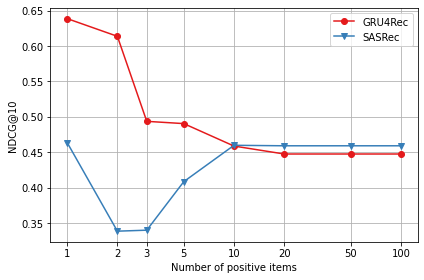

In [35]:
x_column = main_x_column
x_label = main_x_label
plot_name = super_plot_name+"_"+subset_selection["data_params.name"]

ax_instructions["set_xticks"] = {"ticks": table[x_column].unique().astype(int), "labels": table[x_column].unique().astype(int)}
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "upper right"}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)

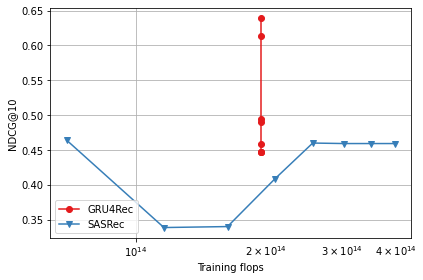

In [36]:
x_column = "train_flops"
x_label = "Training flops"
plot_name = super_plot_name+"_flops_"+subset_selection["data_params.name"]

ax_instructions.pop("set_xticks",None)
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "lower left"}
#ax_instructions["set_title"] = {"label": super_title}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)


In [37]:
x_column = "epoch"
x_label = "Epoch"
y_column = "val_NDCG_@10/dataloader_idx_1"
y_label = "NDCG@10"
ax_instructions["set_xlabel"] = {"xlabel": x_label}

##### SASRec

In [38]:
subset_selection["model.rec_model.name"] = "SASRec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

sas_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
sas_table = hotfix_table(sas_table, y_column) #HOTFIX
sas_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch  step  test_F1_@10  test_F1_@20  test_F1_@5  \
6BJtz0l2NU8Ge0rt 0         0     9          NaN          NaN         NaN   
                 2         1    19          NaN          NaN         NaN   
                 4         2    29          NaN          NaN         NaN   
                 6         3    39          NaN          NaN         NaN   
                 8         4    49          NaN          NaN         NaN   
...                      ...   ...          ...          ...         ...   
snrHAgVEX9Y0mQr6 1190    595  5959          NaN          NaN         NaN   
                 1192    596  5969          NaN          NaN         NaN   
                 1194    597  5979          NaN          NaN         NaN   
                 1196    598  5989          NaN          NaN         NaN   
                 1198    599  5999          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
6BJtz0l2NU8Ge0rt 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
snrHAgVEX9Y0mQr6 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
6BJtz0l2NU8Ge0rt 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
snrHAgVEX9Y0mQr6 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
6BJtz0l2NU8Ge0rt 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
snrHAgVEX9Y0mQr6 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
6BJtz0l2NU8Ge0rt 0              NaN         NaN     amazon_beauty   
                 2              NaN         NaN     amazon_beauty   
                 4              NaN         NaN     amazon_beauty   
                 6     

In [39]:
subset_selection["model.rec_model.name"] = "GRU4Rec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

gru_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
gru_table = hotfix_table(gru_table, y_column) #HOTFIX
gru_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch  step  test_F1_@10  test_F1_@20  test_F1_@5  \
HpcXkTC9nh68di70 0         0     9          NaN          NaN         NaN   
                 2         1    19          NaN          NaN         NaN   
                 4         2    29          NaN          NaN         NaN   
                 6         3    39          NaN          NaN         NaN   
                 8         4    49          NaN          NaN         NaN   
...                      ...   ...          ...          ...         ...   
xrwcsKySQWdvViNH 1190    595  5959          NaN          NaN         NaN   
                 1192    596  5969          NaN          NaN         NaN   
                 1194    597  5979          NaN          NaN         NaN   
                 1196    598  5989          NaN          NaN         NaN   
                 1198    599  5999          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
HpcXkTC9nh68di70 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
xrwcsKySQWdvViNH 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
HpcXkTC9nh68di70 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
xrwcsKySQWdvViNH 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
HpcXkTC9nh68di70 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
xrwcsKySQWdvViNH 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
HpcXkTC9nh68di70 0              NaN         NaN     amazon_beauty   
                 2              NaN         NaN     amazon_beauty   
                 4              NaN         NaN     amazon_beauty   
                 6     

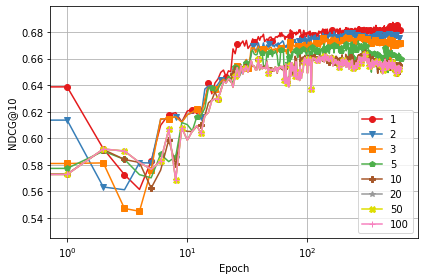

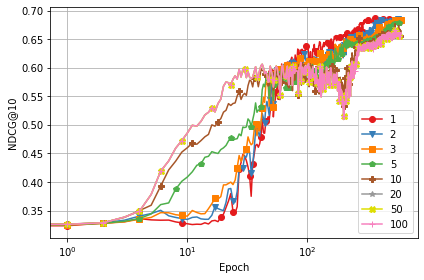

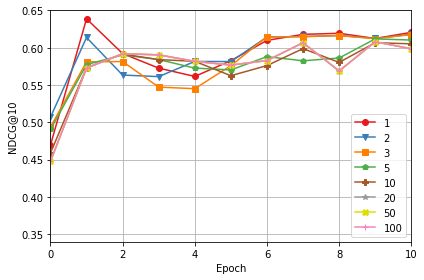

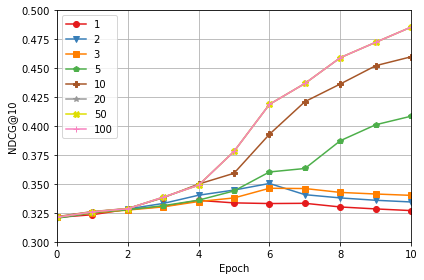

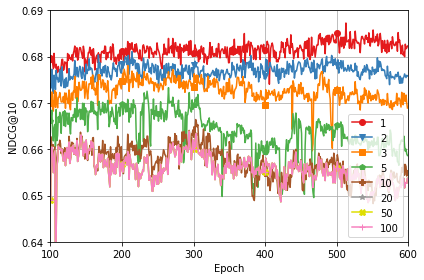

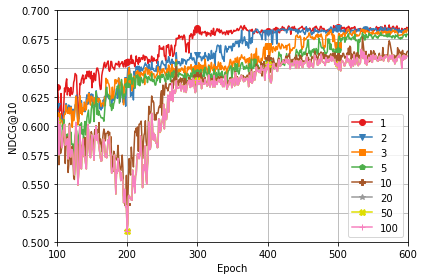

In [40]:
plot_name = "epochs_"+super_plot_name+"_GRU_SAS_"+subset_selection["data_params.name"]

#plot_instructions["subplots"] = {"nrows": 3, "ncols": 2, "figsize": (12,12)}
plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

plot_kwargs = {"markevery": 0.1}

ax_instructions.pop("set_xticks",None)
ax_instructions["legend"] = {"loc": "lower right"}
#ax_instructions["set_title"] = {"label": super_title}

label_convert_dict = {} #x:f"{x} positive item(s)" for x in [1,2,3,5,10,20,50,100]}

repeated_ax_instructions = [ax_instructions.copy() for _ in range(6)]
repeated_ax_instructions[0]["set_ylim"] = {"bottom":0.525}

repeated_ax_instructions[2]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[2]["set_ylim"] = {"bottom":0.34,"top":0.65}
repeated_ax_instructions[2].pop("set_xscale",None)
repeated_ax_instructions[3]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[3]["set_ylim"] = {"bottom":0.30,"top":0.5}
repeated_ax_instructions[3]["legend"] = {"loc": "upper left"}
repeated_ax_instructions[3].pop("set_xscale",None)


repeated_ax_instructions[4]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[4]["set_ylim"] = {"bottom":0.64,"top":0.69}
repeated_ax_instructions[4].pop("set_xscale",None)
repeated_ax_instructions[5]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[5]["set_ylim"] = {"bottom":0.5,"top":0.7}
repeated_ax_instructions[5].pop("set_xscale",None)


repeated_plot_kwargs = [plot_kwargs.copy() for _ in range(6)]
repeated_plot_kwargs[2]["markevery"] = repeated_plot_kwargs[3]["markevery"] = 1
repeated_plot_kwargs[4]["markevery"] = repeated_plot_kwargs[5]["markevery"] = 100

label_a = ["(a)","(b)","(c)","(d)","(e)","(f)"]
label_b = ["GRU","SAS"]*3
label_c = [" - "+x if x !="" else x for x in ["","","start","start","end","end"]]
for i,(rep_ax_instr, rep_plot_kwargs) in enumerate(zip(repeated_ax_instructions,repeated_plot_kwargs)):
    rep_plot_instr = deepcopy(plot_instructions.copy())
    rep_plot_instr["savefig"]["fname"] = plot_instructions["savefig"]["fname"].split(".pdf")[0]+"_"+str(i)+".pdf"
    #rep_ax_instr["set_title"] = {"label": f"{label_a[i]} {label_b[i]}{label_c[i]}"}
    create_plot(rep_plot_instr, data=([gru_table,sas_table]*3)[i], label_columns=[main_x_column], x_column=x_column, y_column=y_column,
            ax_instructions = rep_ax_instr, label_convert_dict = label_convert_dict, plot_type="plot", plot_kwargs=rep_plot_kwargs)

#### Foursquare TKY

In [41]:
subset_selection["data_params.name"] = "foursquare-tky"
subset_selection.pop("model.rec_model.name",None)

'GRU4Rec'

In [42]:
table = generate_table(subset_data(complete_data, subset_selection, subset_keep, merge_columns), rows_labels, column_labels, exp_name = "april_30", save_table=True)
table

,data_params.name,model.rec_model.name,data_params.collator_params.simultaneous_lookforward,MAP_@10,MAP_@20,MAP_@5,NDCG_@10,NDCG_@20,NDCG_@5,Precision_@10,Precision_@20,Precision_@5,Recall_@10,Recall_@20,Recall_@5,test_FLOPS,test_flops,train_FLOPS,train_flops
0,foursquare-tky,GRU4Rec,1,0.2013,0.1295,0.2983,0.7022,0.7158,0.6798,0.0834,0.0444,0.1530,0.8338,0.8875,0.7649,5.430000e+12,1.850000e+12,5.380000e+12,3.330330e+15
1,foursquare-tky,GRU4Rec,2,0.1843,0.1207,0.2671,0.6448,0.6626,0.6218,0.0813,0.0441,0.1485,0.8129,0.8827,0.7423,5.410000e+12,1.850000e+12,5.390000e+12,3.330330e+15
2,foursquare-tky,GRU4Rec,3,0.1505,0.1017,0.2112,0.5398,0.5622,0.5012,0.0739,0.0413,0.1240,0.7388,0.8264,0.6201,5.470000e+12,1.850000e+12,5.390000e+12,3.330330e+15
3,foursquare-tky,GRU4Rec,5,0.1597,0.1074,0.2247,0.5697,0.5914,0.5346,0.0774,0.0430,0.1332,0.7741,0.8596,0.6659,5.440000e+12,1.850000e+12,5.400000e+12,3.330330e+15
4,foursquare-tky,GRU4Rec,10,0.1196,0.0831,0.1648,0.4359,0.4663,0.3961,0.0628,0.0374,0.1008,0.6280,0.7479,0.5041,5.460000e+12,1.850000e+12,5.400000e+12,3.330330e+15
5,foursquare-tky,GRU4Rec,20,0.1089,0.0755,0.1505,0.3952,0.4272,0.3596,0.0563,0.0345,0.0906,0.5630,0.6899,0.4531,5.480000e+12,1.850000e+12,5.410000e+12,3.330330e+15
6,foursquare-tky,GRU4Rec,50,0.1122,0.0782,0.1537,0.4095,0.4400,0.3727,0.0595,0.0358,0.0961,0.5949,0.7157,0.4806,5.440000e+12,1.850000e+12,5.360000e+12,3.330330e+15
7,foursquare-tky,GRU4Rec,100,0.1129,0.0788,0.1549,0.4117,0.4428,0.3740,0.0597,0.0360,0.0960,0.5970,0.7191,0.4802,5.460000e+12,1.850000e+12,5.340000e+12,3.330330e+15
8,foursquare-tky,SASRec,1,0.2193,0.1394,0.3289,0.7600,0.7718,0.7415,0.0866,0.0456,0.1620,0.8657,0.9128,0.8099,7.140000e+12,4.682900e+11,7.090000e+12,8.007500e+14
9,foursquare-tky,SASRec,2,0.1895,0.1231,0.2778,0.6626,0.6788,0.6391,0.0811,0.0438,0.1478,0.8112,0.8753,0.7388,8.490000e+12,5.152500e+11,7.790000e+12,8.852900e+14


In [43]:
y_column = "NDCG_@10"
y_label = y_column.replace("_", "")

ax_instructions = {"set_xscale": {"value": "log"},
                   "set_ylabel": {"ylabel": y_label},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "size":0}},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "width":0}},
                   "legend": {},
                   "grid":{}}

plot_instructions = {"subplots": {"nrows": 1, "ncols": 1, "figsize": (6,4)},
                    "tight_layout":{},
                    "savefig": {"fname": "plot.pdf"},
                    "show":{}}

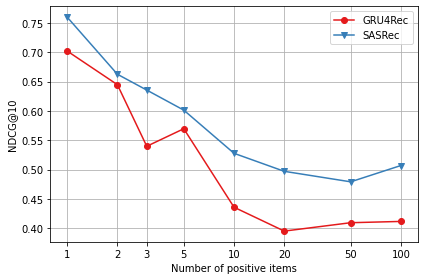

In [44]:
x_column = main_x_column
x_label = main_x_label
plot_name = super_plot_name+"_"+subset_selection["data_params.name"]

ax_instructions["set_xticks"] = {"ticks": table[x_column].unique().astype(int), "labels": table[x_column].unique().astype(int)}
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "upper right"}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)

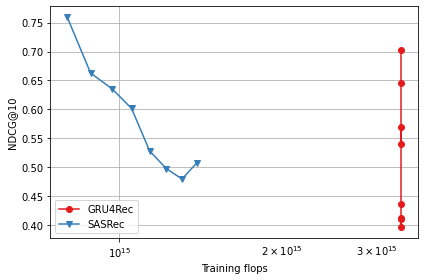

In [45]:
x_column = "train_flops"
x_label = "Training flops"
plot_name = super_plot_name+"_flops_"+subset_selection["data_params.name"]

ax_instructions.pop("set_xticks",None)
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "lower left"}
#ax_instructions["set_title"] = {"label": super_title}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)


In [46]:
x_column = "epoch"
x_label = "Epoch"
y_column = "val_NDCG_@10/dataloader_idx_1"
y_label = "NDCG@10"
ax_instructions["set_xlabel"] = {"xlabel": x_label}

##### SASRec

In [47]:
subset_selection["model.rec_model.name"] = "SASRec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

sas_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
sas_table = hotfix_table(sas_table, y_column) #HOTFIX
sas_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
5qL3WvtyT2FwRGtB 0         0     17          NaN          NaN         NaN   
                 2         1     35          NaN          NaN         NaN   
                 4         2     53          NaN          NaN         NaN   
                 6         3     71          NaN          NaN         NaN   
                 8         4     89          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
xfk16wi3gDTPByGk 1190    595  10727          NaN          NaN         NaN   
                 1192    596  10745          NaN          NaN         NaN   
                 1194    597  10763          NaN          NaN         NaN   
                 1196    598  10781          NaN          NaN         NaN   
                 1198    599  10799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
5qL3WvtyT2FwRGtB 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
xfk16wi3gDTPByGk 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
5qL3WvtyT2FwRGtB 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
xfk16wi3gDTPByGk 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
5qL3WvtyT2FwRGtB 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
xfk16wi3gDTPByGk 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
5qL3WvtyT2FwRGtB 0              NaN         NaN    foursquare-tky   
                 2              NaN         NaN    foursquare-tky   
                 4              NaN         NaN    foursquare-tky   
           

In [48]:
subset_selection["model.rec_model.name"] = "GRU4Rec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

gru_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
gru_table = hotfix_table(gru_table, y_column) #HOTFIX
gru_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
FJnLB2mpv6OVp5Gk 0         0     17          NaN          NaN         NaN   
                 2         1     35          NaN          NaN         NaN   
                 4         2     53          NaN          NaN         NaN   
                 6         3     71          NaN          NaN         NaN   
                 8         4     89          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
xJJ9K44SQ7woxFse 1190    595  10727          NaN          NaN         NaN   
                 1192    596  10745          NaN          NaN         NaN   
                 1194    597  10763          NaN          NaN         NaN   
                 1196    598  10781          NaN          NaN         NaN   
                 1198    599  10799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
FJnLB2mpv6OVp5Gk 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
xJJ9K44SQ7woxFse 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
FJnLB2mpv6OVp5Gk 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
xJJ9K44SQ7woxFse 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
FJnLB2mpv6OVp5Gk 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
xJJ9K44SQ7woxFse 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
FJnLB2mpv6OVp5Gk 0              NaN         NaN    foursquare-tky   
                 2              NaN         NaN    foursquare-tky   
                 4              NaN         NaN    foursquare-tky   
           

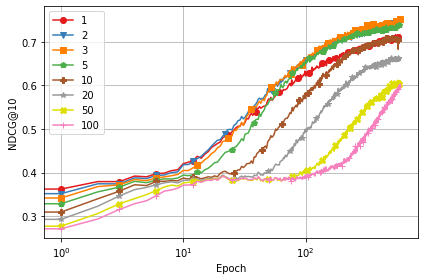

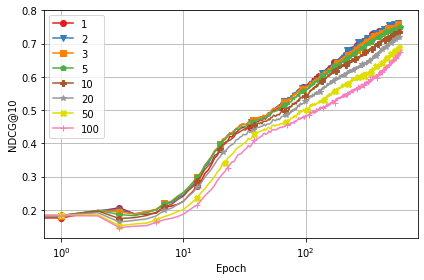

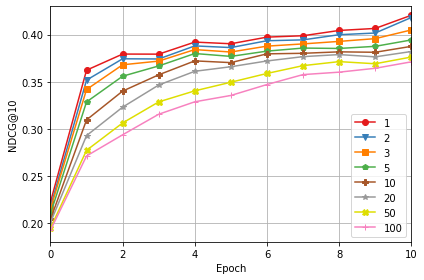

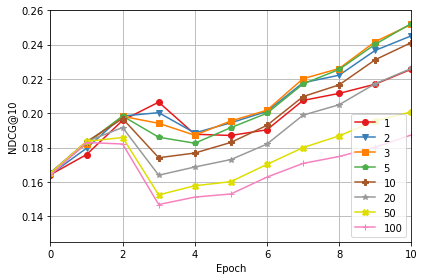

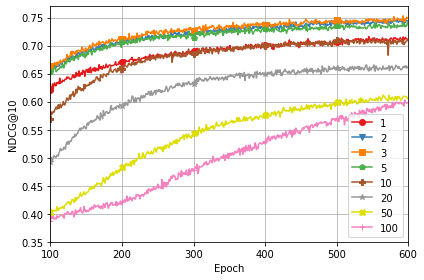

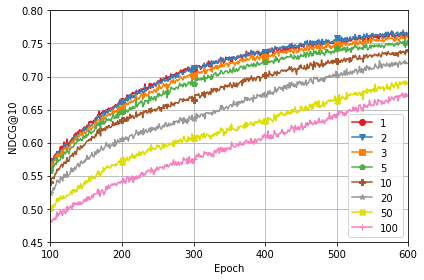

In [49]:
plot_name = "epochs_"+super_plot_name+"_GRU_SAS_"+subset_selection["data_params.name"]

#plot_instructions["subplots"] = {"nrows": 3, "ncols": 2, "figsize": (12,12)}
plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

plot_kwargs = {"markevery": 0.1}

ax_instructions.pop("set_xticks",None)
ax_instructions["legend"] = {"loc": "lower right"}
#ax_instructions["set_title"] = {"label": super_title}

label_convert_dict = {} #x:f"{x} positive item(s)" for x in [1,2,3,5,10,20,50,100]}

repeated_ax_instructions = [ax_instructions.copy() for _ in range(6)]
repeated_ax_instructions[0]["set_ylim"] = {"bottom":0.25}
repeated_ax_instructions[0]["legend"] = {"loc": "upper left"}
repeated_ax_instructions[1]["legend"] = {"loc": "upper left"}


repeated_ax_instructions[2]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[2]["set_ylim"] = {"bottom":0.18,"top":0.43}
repeated_ax_instructions[2].pop("set_xscale",None)
repeated_ax_instructions[3]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[3]["set_ylim"] = {"bottom":0.125,"top":0.26}
repeated_ax_instructions[3].pop("set_xscale",None)


repeated_ax_instructions[4]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[4]["set_ylim"] = {"bottom":0.35,"top":0.77}
repeated_ax_instructions[4].pop("set_xscale",None)
repeated_ax_instructions[5]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[5]["set_ylim"] = {"bottom":0.45,"top":0.80}
repeated_ax_instructions[5].pop("set_xscale",None)


repeated_plot_kwargs = [plot_kwargs.copy() for _ in range(6)]
repeated_plot_kwargs[2]["markevery"] = repeated_plot_kwargs[3]["markevery"] = 1
repeated_plot_kwargs[4]["markevery"] = repeated_plot_kwargs[5]["markevery"] = 100

label_a = ["(a)","(b)","(c)","(d)","(e)","(f)"]
label_b = ["GRU","SAS"]*3
label_c = [" - "+x if x !="" else x for x in ["","","start","start","end","end"]]
for i,(rep_ax_instr, rep_plot_kwargs) in enumerate(zip(repeated_ax_instructions,repeated_plot_kwargs)):
    rep_plot_instr = deepcopy(plot_instructions.copy())
    rep_plot_instr["savefig"]["fname"] = plot_instructions["savefig"]["fname"].split(".pdf")[0]+"_"+str(i)+".pdf"
    #rep_ax_instr["set_title"] = {"label": f"{label_a[i]} {label_b[i]}{label_c[i]}"}
    create_plot(rep_plot_instr, data=([gru_table,sas_table]*3)[i], label_columns=[main_x_column], x_column=x_column, y_column=y_column,
            ax_instructions = rep_ax_instr, label_convert_dict = label_convert_dict, plot_type="plot", plot_kwargs=rep_plot_kwargs)

#### ML-1M

In [50]:
subset_selection["data_params.name"] = "ml-1m"
subset_selection.pop("model.rec_model.name",None)

'GRU4Rec'

In [51]:
table = generate_table(subset_data(complete_data, subset_selection, subset_keep, merge_columns), rows_labels, column_labels, exp_name = "april_30", save_table=True)
table

,data_params.name,model.rec_model.name,data_params.collator_params.simultaneous_lookforward,MAP_@10,MAP_@20,MAP_@5,NDCG_@10,NDCG_@20,NDCG_@5,Precision_@10,Precision_@20,Precision_@5,Recall_@10,Recall_@20,Recall_@5,test_FLOPS,test_flops,train_FLOPS,train_flops
0,ml-1m,GRU4Rec,1,0.1566,0.1062,0.2175,0.5594,0.5824,0.5239,0.0784,0.0437,0.1348,0.7838,0.8747,0.6740,4.940000e+12,1.240000e+12,4.920000e+12,2.224740e+15
1,ml-1m,GRU4Rec,2,0.1419,0.0981,0.1926,0.5134,0.5386,0.4724,0.0756,0.0428,0.1258,0.7558,0.8553,0.6291,4.930000e+12,1.240000e+12,4.900000e+12,2.224740e+15
2,ml-1m,GRU4Rec,3,0.1371,0.0957,0.1842,0.4989,0.5265,0.4542,0.0749,0.0429,0.1223,0.7488,0.8575,0.6113,4.890000e+12,1.240000e+12,4.880000e+12,2.224740e+15
3,ml-1m,GRU4Rec,5,0.1341,0.0941,0.1785,0.4893,0.5163,0.4451,0.0748,0.0427,0.1224,0.7482,0.8543,0.6118,4.910000e+12,1.240000e+12,4.870000e+12,2.224740e+15
4,ml-1m,GRU4Rec,10,0.1176,0.0848,0.1523,0.4367,0.4721,0.3865,0.0699,0.0419,0.1089,0.6985,0.8381,0.5444,4.910000e+12,1.240000e+12,4.850000e+12,2.224740e+15
5,ml-1m,GRU4Rec,20,0.1100,0.0802,0.1418,0.4118,0.4502,0.3616,0.0667,0.0409,0.1024,0.6672,0.8185,0.5121,4.910000e+12,1.240000e+12,4.820000e+12,2.224740e+15
6,ml-1m,GRU4Rec,50,0.0911,0.0687,0.1141,0.3499,0.3930,0.2945,0.0596,0.0383,0.0849,0.5962,0.7664,0.4245,4.840000e+12,1.240000e+12,4.750000e+12,2.224740e+15
7,ml-1m,GRU4Rec,100,0.0653,0.0515,0.0795,0.2577,0.3057,0.2084,0.0461,0.0326,0.0615,0.4614,0.6520,0.3076,4.820000e+12,1.240000e+12,4.680000e+12,2.224740e+15
8,ml-1m,SASRec,1,0.1643,0.1106,0.2297,0.5848,0.6046,0.5504,0.0806,0.0442,0.1401,0.8063,0.8839,0.7003,1.540000e+12,2.439200e+11,1.140000e+12,3.277400e+14
9,ml-1m,SASRec,2,0.1571,0.1067,0.2172,0.5608,0.5830,0.5270,0.0791,0.0439,0.1373,0.7906,0.8776,0.6864,1.500000e+12,2.439200e+11,1.120000e+12,3.277400e+14


In [52]:
x_column = main_x_column
x_label = main_x_label
y_column = "NDCG_@10"
y_label = y_column.replace("_", "")

ax_instructions = {"set_xscale": {"value": "log"},
                   "set_ylabel": {"ylabel": y_label},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "size":0}},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "width":0}},
                   "legend": {},
                   "grid":{}}

plot_instructions = {"subplots": {"nrows": 1, "ncols": 1, "figsize": (6,4)},
                    "tight_layout":{},
                    "savefig": {"fname": "plot.pdf"},
                    "show":{}}

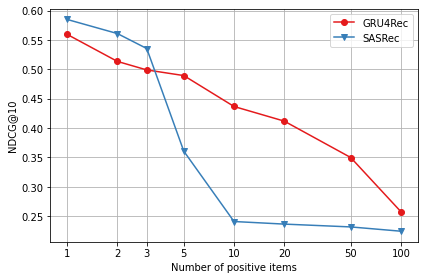

In [53]:
plot_name = super_plot_name+"_"+subset_selection["data_params.name"]

ax_instructions["set_xticks"] = {"ticks": table[x_column].unique().astype(int), "labels": table[x_column].unique().astype(int)}
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "upper right"}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)

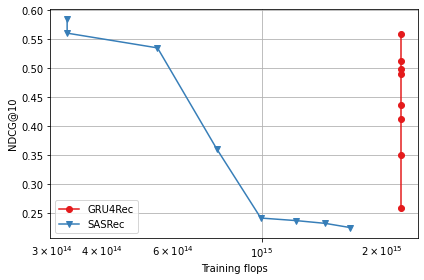

In [54]:
x_column = "train_flops"
x_label = "Training flops"
plot_name = super_plot_name+"_flops_"+subset_selection["data_params.name"]

ax_instructions.pop("set_xticks",None)
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "lower left"}
#ax_instructions["set_title"] = {"label": super_title}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)


In [55]:
x_column = "epoch"
x_label = "Epoch"
y_column = "val_NDCG_@10/dataloader_idx_1"
y_label = "NDCG@10"
ax_instructions["set_xlabel"] = {"xlabel": x_label}

##### SASRec

In [56]:
subset_selection["model.rec_model.name"] = "SASRec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

sas_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
sas_table = hotfix_table(sas_table, y_column) #HOTFIX
sas_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
7ev5cCHoXB9vYE1z 0         0     47          NaN          NaN         NaN   
                 2         1     95          NaN          NaN         NaN   
                 4         2    143          NaN          NaN         NaN   
                 6         3    191          NaN          NaN         NaN   
                 8         4    239          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
sDM1mgQZrR9euJ02 1190    595  28607          NaN          NaN         NaN   
                 1192    596  28655          NaN          NaN         NaN   
                 1194    597  28703          NaN          NaN         NaN   
                 1196    598  28751          NaN          NaN         NaN   
                 1198    599  28799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
7ev5cCHoXB9vYE1z 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
sDM1mgQZrR9euJ02 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
7ev5cCHoXB9vYE1z 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
sDM1mgQZrR9euJ02 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
7ev5cCHoXB9vYE1z 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
sDM1mgQZrR9euJ02 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
7ev5cCHoXB9vYE1z 0              NaN         NaN             ml-1m   
                 2              NaN         NaN             ml-1m   
                 4              NaN         NaN             ml-1m   
           

In [57]:
subset_selection["model.rec_model.name"] = "GRU4Rec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

gru_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
gru_table = hotfix_table(gru_table, y_column) #HOTFIX
gru_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
3YvqrtIwqwN0cbUf 0         0     47          NaN          NaN         NaN   
                 2         1     95          NaN          NaN         NaN   
                 4         2    143          NaN          NaN         NaN   
                 6         3    191          NaN          NaN         NaN   
                 8         4    239          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
wGcyn1FEh5sNJ3lO 1190    595  28607          NaN          NaN         NaN   
                 1192    596  28655          NaN          NaN         NaN   
                 1194    597  28703          NaN          NaN         NaN   
                 1196    598  28751          NaN          NaN         NaN   
                 1198    599  28799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
3YvqrtIwqwN0cbUf 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
wGcyn1FEh5sNJ3lO 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
3YvqrtIwqwN0cbUf 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
wGcyn1FEh5sNJ3lO 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
3YvqrtIwqwN0cbUf 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
wGcyn1FEh5sNJ3lO 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
3YvqrtIwqwN0cbUf 0              NaN         NaN             ml-1m   
                 2              NaN         NaN             ml-1m   
                 4              NaN         NaN             ml-1m   
           

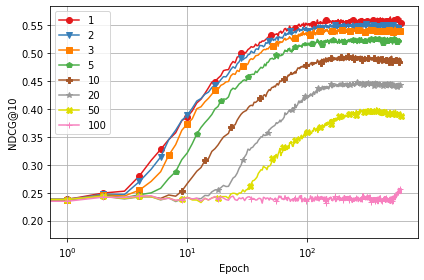

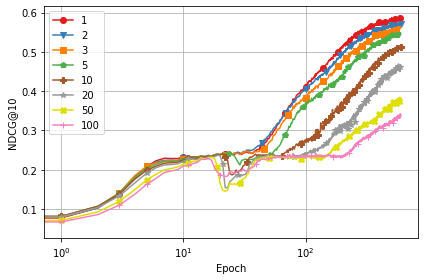

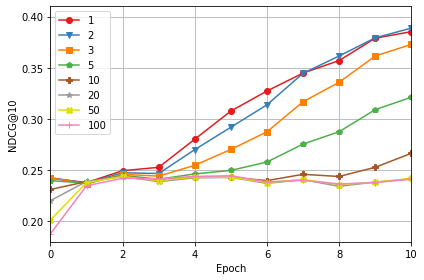

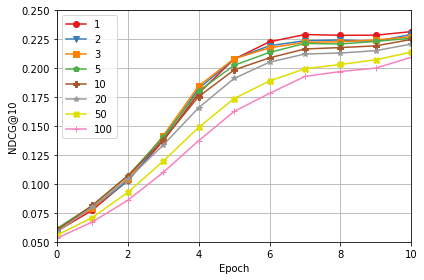

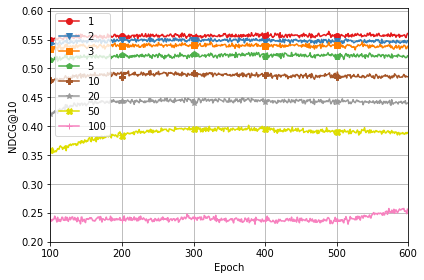

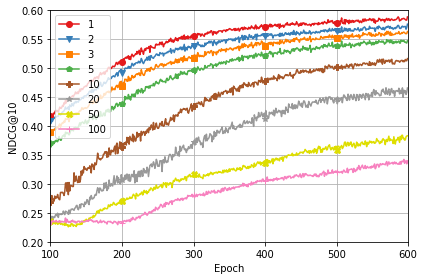

In [58]:
plot_name = "epochs_"+super_plot_name+"_GRU_SAS_"+subset_selection["data_params.name"]

#plot_instructions["subplots"] = {"nrows": 3, "ncols": 2, "figsize": (12,12)}
plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

plot_kwargs = {"markevery": 0.1}

ax_instructions.pop("set_xticks",None)
ax_instructions["legend"] = {"loc": "upper left"}
#ax_instructions["set_title"] = {"label": super_title}

label_convert_dict = {} #x:f"{x} positive item(s)" for x in [1,2,3,5,10,20,50,100]}

repeated_ax_instructions = [ax_instructions.copy() for _ in range(6)]
repeated_ax_instructions[2]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[2]["set_ylim"] = {"bottom":0.18,"top":0.41}
repeated_ax_instructions[2].pop("set_xscale",None)
repeated_ax_instructions[3]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[3]["set_ylim"] = {"bottom":0.05,"top":0.25}
repeated_ax_instructions[3].pop("set_xscale",None)


repeated_ax_instructions[4]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[4]["set_ylim"] = {"bottom":0.2,"top":0.605}
repeated_ax_instructions[4].pop("set_xscale",None)
repeated_ax_instructions[5]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[5]["set_ylim"] = {"bottom":0.2,"top":0.60}
repeated_ax_instructions[5].pop("set_xscale",None)


repeated_plot_kwargs = [plot_kwargs.copy() for _ in range(6)]
repeated_plot_kwargs[2]["markevery"] = repeated_plot_kwargs[3]["markevery"] = 1
repeated_plot_kwargs[4]["markevery"] = repeated_plot_kwargs[5]["markevery"] = 100

label_a = ["(a)","(b)","(c)","(d)","(e)","(f)"]
label_b = ["GRU","SAS"]*3
label_c = [" - "+x if x !="" else x for x in ["","","start","start","end","end"]]
for i,(rep_ax_instr, rep_plot_kwargs) in enumerate(zip(repeated_ax_instructions,repeated_plot_kwargs)):
    rep_plot_instr = deepcopy(plot_instructions.copy())
    rep_plot_instr["savefig"]["fname"] = plot_instructions["savefig"]["fname"].split(".pdf")[0]+"_"+str(i)+".pdf"
    #rep_ax_instr["set_title"] = {"label": f"{label_a[i]} {label_b[i]}{label_c[i]}"}
    create_plot(rep_plot_instr, data=([gru_table,sas_table]*3)[i], label_columns=[main_x_column], x_column=x_column, y_column=y_column,
            ax_instructions = rep_ax_instr, label_convert_dict = label_convert_dict, plot_type="plot", plot_kwargs=rep_plot_kwargs)

### Num negatives

In [59]:
main_x_column = "data_params.collator_params.num_negatives.train"
main_x_label = "Number of negative items"
super_plot_name = "negatives_NDCG@10"
super_title = "Performance with varying number of negative items"

In [60]:
rows_label_to_add = [main_x_column]
rows_labels = main_rows_labels + rows_label_to_add

subset_selection = {"data_params.collator_params.simultaneous_lookforward":1}

#### Amazon-beauty

In [61]:
subset_selection["data_params.name"] = "amazon_beauty"
subset_selection.pop("model.rec_model.name",None)

In [62]:
table = generate_table(subset_data(complete_data, subset_selection, subset_keep, merge_columns), rows_labels, column_labels, exp_name = "april_30", save_table=True)
table

,data_params.name,model.rec_model.name,data_params.collator_params.num_negatives.train,MAP_@10,MAP_@20,MAP_@5,NDCG_@10,NDCG_@20,NDCG_@5,Precision_@10,Precision_@20,Precision_@5,Recall_@10,Recall_@20,Recall_@5,test_FLOPS,test_flops,train_FLOPS,train_flops
0,amazon_beauty,GRU4Rec,1,0.1865,0.1165,0.2855,0.6387,0.6457,0.6340,0.0683,0.0356,0.1338,0.6829,0.7111,0.6688,3.600000e+12,1.080500e+11,3.820000e+12,1.945400e+14
1,amazon_beauty,GRU4Rec,2,0.1653,0.1062,0.2427,0.5692,0.5763,0.5597,0.0690,0.0359,0.1322,0.6900,0.7182,0.6609,3.550000e+12,1.080500e+11,3.870000e+12,1.945400e+14
2,amazon_beauty,GRU4Rec,3,0.1530,0.1000,0.2184,0.5302,0.5409,0.5194,0.0686,0.0365,0.1308,0.6860,0.7300,0.6538,3.660000e+12,1.080500e+11,3.880000e+12,1.945400e+14
3,amazon_beauty,GRU4Rec,5,0.1730,0.1104,0.2578,0.5926,0.6030,0.5854,0.0691,0.0366,0.1338,0.6907,0.7316,0.6688,3.680000e+12,1.080500e+11,3.880000e+12,1.945400e+14
4,amazon_beauty,GRU4Rec,10,0.1650,0.1063,0.2416,0.5672,0.5765,0.5606,0.0690,0.0363,0.1341,0.6900,0.7268,0.6703,3.700000e+12,1.080500e+11,3.880000e+12,1.945400e+14
5,amazon_beauty,GRU4Rec,20,0.1693,0.1084,0.2498,0.5811,0.5888,0.5747,0.0695,0.0363,0.1352,0.6954,0.7268,0.6758,3.540000e+12,1.080500e+11,3.880000e+12,1.945400e+14
6,amazon_beauty,GRU4Rec,50,0.2016,0.1246,0.3127,0.6909,0.6940,0.6872,0.0706,0.0359,0.1388,0.7057,0.7182,0.6939,3.630000e+12,1.080500e+11,3.850000e+12,1.945400e+14
7,amazon_beauty,GRU4Rec,100,0.2006,0.1240,0.3113,0.6869,0.6915,0.6836,0.0700,0.0359,0.1380,0.7002,0.7182,0.6900,3.580000e+12,1.080500e+11,3.850000e+12,1.945400e+14
8,amazon_beauty,SASRec,1,0.1246,0.0858,0.1682,0.4638,0.4744,0.4081,0.0677,0.0359,0.1019,0.6774,0.7190,0.5094,1.420000e+12,5.145000e+10,1.140000e+12,6.914000e+13
9,amazon_beauty,SASRec,2,0.1744,0.1118,0.2586,0.6003,0.6094,0.5917,0.0714,0.0375,0.1372,0.7135,0.7496,0.6860,1.520000e+12,5.145000e+10,1.170000e+12,6.914000e+13


In [63]:
y_column = "NDCG_@10"
y_label = y_column.replace("_", "")

ax_instructions = {"set_xscale": {"value": "log"},
                   "set_ylabel": {"ylabel": y_label},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "size":0}},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "width":0}},
                   "legend": {},
                   "grid":{}}

plot_instructions = {"subplots": {"nrows": 1, "ncols": 1, "figsize": (6,4)},
                    "tight_layout":{},
                    "savefig": {"fname": "plot.pdf"},
                    "show":{}}

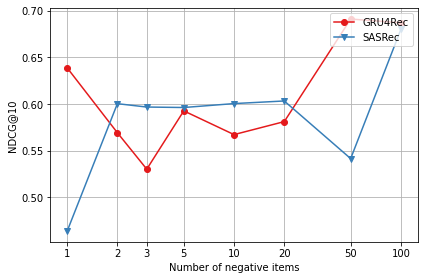

In [64]:
x_column = main_x_column
x_label = main_x_label
plot_name = super_plot_name+"_"+subset_selection["data_params.name"]

ax_instructions["set_xticks"] = {"ticks": table[x_column].unique().astype(int), "labels": table[x_column].unique().astype(int)}
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "upper right"}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)

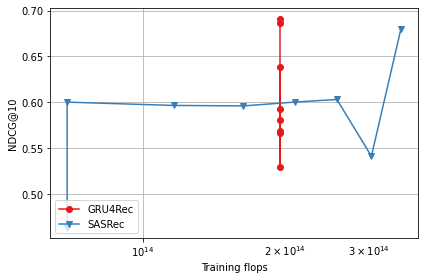

In [65]:
x_column = "train_flops"
x_label = "Training flops"
plot_name = super_plot_name+"_flops_"+subset_selection["data_params.name"]

ax_instructions.pop("set_xticks",None)
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "lower left"}
#ax_instructions["set_title"] = {"label": super_title}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)


In [66]:
x_column = "epoch"
x_label = "Epoch"
y_column = "val_NDCG_@10/dataloader_idx_1"
y_label = "NDCG@10"
ax_instructions["set_xlabel"] = {"xlabel": x_label}

##### SASRec

In [67]:
subset_selection["model.rec_model.name"] = "SASRec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

sas_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
sas_table = hotfix_table(sas_table, y_column) #HOTFIX
sas_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch  step  test_F1_@10  test_F1_@20  test_F1_@5  \
E1XjGCYk9NhebtwB 0         0     9          NaN          NaN         NaN   
                 2         1    19          NaN          NaN         NaN   
                 4         2    29          NaN          NaN         NaN   
                 6         3    39          NaN          NaN         NaN   
                 8         4    49          NaN          NaN         NaN   
...                      ...   ...          ...          ...         ...   
rLQi99STMupgaPTC 1190    595  5959          NaN          NaN         NaN   
                 1192    596  5969          NaN          NaN         NaN   
                 1194    597  5979          NaN          NaN         NaN   
                 1196    598  5989          NaN          NaN         NaN   
                 1198    599  5999          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
E1XjGCYk9NhebtwB 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
rLQi99STMupgaPTC 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
E1XjGCYk9NhebtwB 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
rLQi99STMupgaPTC 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
E1XjGCYk9NhebtwB 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
rLQi99STMupgaPTC 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
E1XjGCYk9NhebtwB 0              NaN         NaN     amazon_beauty   
                 2              NaN         NaN     amazon_beauty   
                 4              NaN         NaN     amazon_beauty   
                 6     

In [68]:
subset_selection["model.rec_model.name"] = "GRU4Rec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

gru_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
gru_table = hotfix_table(gru_table, y_column) #HOTFIX
gru_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch  step  test_F1_@10  test_F1_@20  test_F1_@5  \
02aTlr7kC6tzuSqW 0         0     9          NaN          NaN         NaN   
                 2         1    19          NaN          NaN         NaN   
                 4         2    29          NaN          NaN         NaN   
                 6         3    39          NaN          NaN         NaN   
                 8         4    49          NaN          NaN         NaN   
...                      ...   ...          ...          ...         ...   
w5EK0LMa3l9y8HDZ 1190    595  5959          NaN          NaN         NaN   
                 1192    596  5969          NaN          NaN         NaN   
                 1194    597  5979          NaN          NaN         NaN   
                 1196    598  5989          NaN          NaN         NaN   
                 1198    599  5999          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
02aTlr7kC6tzuSqW 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
w5EK0LMa3l9y8HDZ 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
02aTlr7kC6tzuSqW 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
w5EK0LMa3l9y8HDZ 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
02aTlr7kC6tzuSqW 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
w5EK0LMa3l9y8HDZ 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
02aTlr7kC6tzuSqW 0              NaN         NaN     amazon_beauty   
                 2              NaN         NaN     amazon_beauty   
                 4              NaN         NaN     amazon_beauty   
                 6     

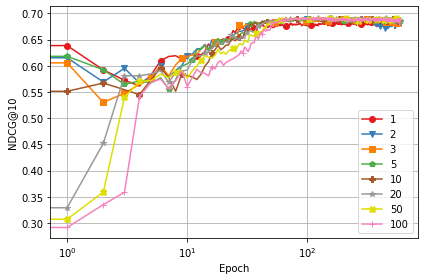

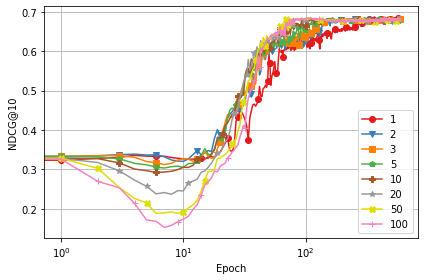

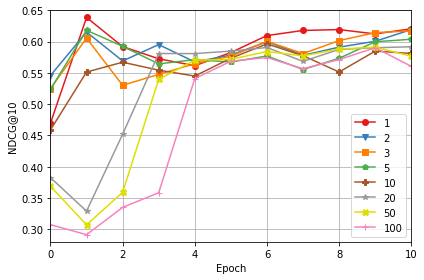

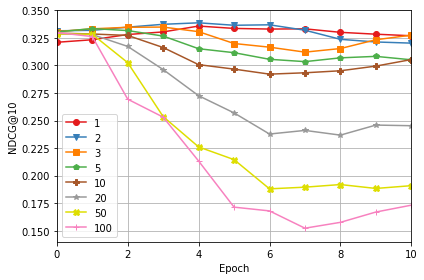

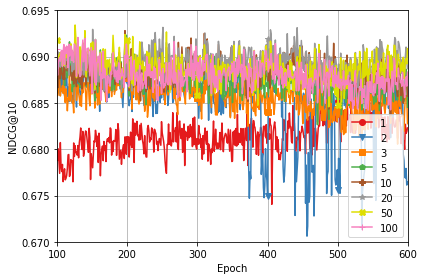

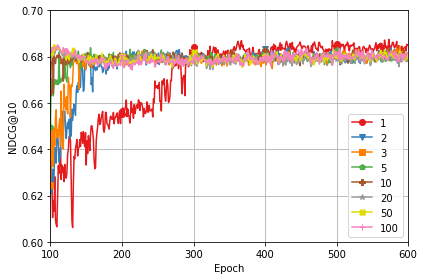

In [69]:
plot_name = "epochs_"+super_plot_name+"_GRU_SAS_"+subset_selection["data_params.name"]

#plot_instructions["subplots"] = {"nrows": 3, "ncols": 2, "figsize": (12,12)}
plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

plot_kwargs = {"markevery": 0.1}

ax_instructions.pop("set_xticks",None)
ax_instructions["legend"] = {"loc": "lower right"}
#ax_instructions["set_title"] = {"label": super_title}

label_convert_dict = {} #x:f"{x} positive item(s)" for x in [1,2,3,5,10,20,50,100]}

repeated_ax_instructions = [ax_instructions.copy() for _ in range(6)]
#repeated_ax_instructions[0]["set_ylim"] = {"bottom":0.525}

repeated_ax_instructions[2]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[2]["set_ylim"] = {"bottom":0.28,"top":0.65}
repeated_ax_instructions[2].pop("set_xscale",None)
repeated_ax_instructions[3]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[3]["set_ylim"] = {"bottom":0.14,"top":0.35}
repeated_ax_instructions[3]["legend"] = {"loc": "lower left"}
repeated_ax_instructions[3].pop("set_xscale",None)


repeated_ax_instructions[4]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[4]["set_ylim"] = {"bottom":0.67,"top":0.695}
repeated_ax_instructions[4].pop("set_xscale",None)
repeated_ax_instructions[5]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[5]["set_ylim"] = {"bottom":0.6,"top":0.7}
repeated_ax_instructions[5].pop("set_xscale",None)


repeated_plot_kwargs = [plot_kwargs.copy() for _ in range(6)]
repeated_plot_kwargs[2]["markevery"] = repeated_plot_kwargs[3]["markevery"] = 1
repeated_plot_kwargs[4]["markevery"] = repeated_plot_kwargs[5]["markevery"] = 100

label_a = ["(a)","(b)","(c)","(d)","(e)","(f)"]
label_b = ["GRU","SAS"]*3
label_c = [" - "+x if x !="" else x for x in ["","","start","start","end","end"]]
for i,(rep_ax_instr, rep_plot_kwargs) in enumerate(zip(repeated_ax_instructions,repeated_plot_kwargs)):
    rep_plot_instr = deepcopy(plot_instructions.copy())
    rep_plot_instr["savefig"]["fname"] = plot_instructions["savefig"]["fname"].split(".pdf")[0]+"_"+str(i)+".pdf"
    #rep_ax_instr["set_title"] = {"label": f"{label_a[i]} {label_b[i]}{label_c[i]}"}
    create_plot(rep_plot_instr, data=([gru_table,sas_table]*3)[i], label_columns=[main_x_column], x_column=x_column, y_column=y_column,
            ax_instructions = rep_ax_instr, label_convert_dict = label_convert_dict, plot_type="plot", plot_kwargs=rep_plot_kwargs)

#### Foursquare TKY

In [70]:
subset_selection["data_params.name"] = "foursquare-tky"
subset_selection.pop("model.rec_model.name",None)

'GRU4Rec'

In [71]:
table = generate_table(subset_data(complete_data, subset_selection, subset_keep, merge_columns), rows_labels, column_labels, exp_name = "april_30", save_table=True)
table

,data_params.name,model.rec_model.name,data_params.collator_params.num_negatives.train,MAP_@10,MAP_@20,MAP_@5,NDCG_@10,NDCG_@20,NDCG_@5,Precision_@10,Precision_@20,Precision_@5,Recall_@10,Recall_@20,Recall_@5,test_FLOPS,test_flops,train_FLOPS,train_flops
0,foursquare-tky,GRU4Rec,1,0.2013,0.1295,0.2983,0.7022,0.7158,0.6798,0.0834,0.0444,0.1530,0.8338,0.8875,0.7649,5.430000e+12,1.850000e+12,5.380000e+12,3.330330e+15
1,foursquare-tky,GRU4Rec,2,0.2072,0.1329,0.3082,0.7213,0.7343,0.7002,0.0846,0.0449,0.1563,0.8461,0.8971,0.7815,5.510000e+12,1.850000e+12,5.470000e+12,3.330330e+15
2,foursquare-tky,GRU4Rec,3,0.2081,0.1333,0.3104,0.7237,0.7370,0.7056,0.0844,0.0448,0.1575,0.8443,0.8966,0.7876,5.470000e+12,1.850000e+12,5.470000e+12,3.330330e+15
3,foursquare-tky,GRU4Rec,5,0.2075,0.1328,0.3096,0.7230,0.7353,0.7010,0.0843,0.0446,0.1550,0.8430,0.8918,0.7750,5.470000e+12,1.850000e+12,5.460000e+12,3.330330e+15
4,foursquare-tky,GRU4Rec,10,0.2066,0.1323,0.3079,0.7189,0.7312,0.6990,0.0840,0.0444,0.1558,0.8404,0.8888,0.7789,5.410000e+12,1.850000e+12,5.450000e+12,3.330330e+15
5,foursquare-tky,GRU4Rec,20,0.2078,0.1332,0.3100,0.7247,0.7386,0.7043,0.0846,0.0450,0.1565,0.8461,0.9006,0.7824,5.450000e+12,1.850000e+12,5.460000e+12,3.330330e+15
6,foursquare-tky,GRU4Rec,50,0.2073,0.1329,0.3093,0.7221,0.7381,0.7016,0.0841,0.0452,0.1555,0.8413,0.9045,0.7776,5.520000e+12,1.850000e+12,5.430000e+12,3.330330e+15
7,foursquare-tky,GRU4Rec,100,0.2117,0.1352,0.3169,0.7356,0.7495,0.7175,0.0849,0.0452,0.1584,0.8487,0.9036,0.7920,5.510000e+12,1.850000e+12,5.440000e+12,3.330330e+15
8,foursquare-tky,SASRec,1,0.2193,0.1394,0.3289,0.7600,0.7718,0.7415,0.0866,0.0456,0.1620,0.8657,0.9128,0.8099,7.140000e+12,4.682900e+11,7.090000e+12,8.007500e+14
9,foursquare-tky,SASRec,2,0.2225,0.1413,0.3348,0.7714,0.7816,0.7526,0.0874,0.0457,0.1633,0.8740,0.9137,0.8164,6.440000e+12,4.213200e+11,6.050000e+12,7.162100e+14


In [72]:
y_column = "NDCG_@10"
y_label = y_column.replace("_", "")

ax_instructions = {"set_xscale": {"value": "log"},
                   "set_ylabel": {"ylabel": y_label},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "size":0}},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "width":0}},
                   "legend": {},
                   "grid":{}}

plot_instructions = {"subplots": {"nrows": 1, "ncols": 1, "figsize": (6,4)},
                    "tight_layout":{},
                    "savefig": {"fname": "plot.pdf"},
                    "show":{}}

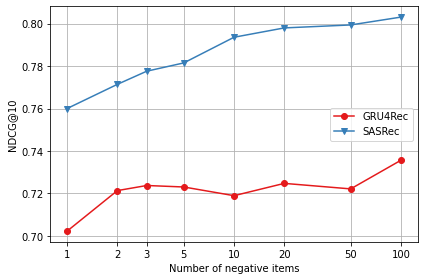

In [73]:
x_column = main_x_column
x_label = main_x_label
plot_name = super_plot_name+"_"+subset_selection["data_params.name"]

ax_instructions["set_xticks"] = {"ticks": table[x_column].unique().astype(int), "labels": table[x_column].unique().astype(int)}
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "center right"}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)

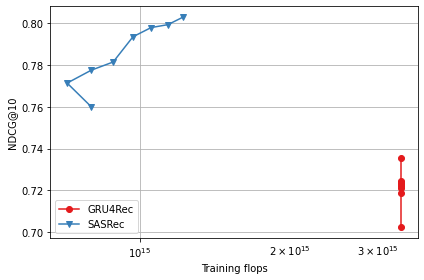

In [74]:
x_column = "train_flops"
x_label = "Training flops"
plot_name = super_plot_name+"_flops_"+subset_selection["data_params.name"]

ax_instructions.pop("set_xticks",None)
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "lower left"}
#ax_instructions["set_title"] = {"label": super_title}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)


In [75]:
x_column = "epoch"
x_label = "Epoch"
y_column = "val_NDCG_@10/dataloader_idx_1"
y_label = "NDCG@10"
ax_instructions["set_xlabel"] = {"xlabel": x_label}

##### SASRec

In [76]:
subset_selection["model.rec_model.name"] = "SASRec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

sas_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
sas_table = hotfix_table(sas_table, y_column) #HOTFIX
sas_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
645fTGfMU3Gca65a 0         0     17          NaN          NaN         NaN   
                 2         1     35          NaN          NaN         NaN   
                 4         2     53          NaN          NaN         NaN   
                 6         3     71          NaN          NaN         NaN   
                 8         4     89          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
on3EZb82LsG78VlZ 1190    595  10727          NaN          NaN         NaN   
                 1192    596  10745          NaN          NaN         NaN   
                 1194    597  10763          NaN          NaN         NaN   
                 1196    598  10781          NaN          NaN         NaN   
                 1198    599  10799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
645fTGfMU3Gca65a 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
on3EZb82LsG78VlZ 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
645fTGfMU3Gca65a 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
on3EZb82LsG78VlZ 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
645fTGfMU3Gca65a 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
on3EZb82LsG78VlZ 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
645fTGfMU3Gca65a 0              NaN         NaN    foursquare-tky   
                 2              NaN         NaN    foursquare-tky   
                 4              NaN         NaN    foursquare-tky   
           

In [77]:
subset_selection["model.rec_model.name"] = "GRU4Rec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

gru_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
gru_table = hotfix_table(gru_table, y_column) #HOTFIX
gru_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
ELZDMpk9iYiOedlP 0         0     17          NaN          NaN         NaN   
                 2         1     35          NaN          NaN         NaN   
                 4         2     53          NaN          NaN         NaN   
                 6         3     71          NaN          NaN         NaN   
                 8         4     89          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
xWaj0hxvcvd1doh9 1190    595  10727          NaN          NaN         NaN   
                 1192    596  10745          NaN          NaN         NaN   
                 1194    597  10763          NaN          NaN         NaN   
                 1196    598  10781          NaN          NaN         NaN   
                 1198    599  10799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
ELZDMpk9iYiOedlP 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
xWaj0hxvcvd1doh9 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
ELZDMpk9iYiOedlP 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
xWaj0hxvcvd1doh9 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
ELZDMpk9iYiOedlP 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
xWaj0hxvcvd1doh9 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
ELZDMpk9iYiOedlP 0              NaN         NaN    foursquare-tky   
                 2              NaN         NaN    foursquare-tky   
                 4              NaN         NaN    foursquare-tky   
           

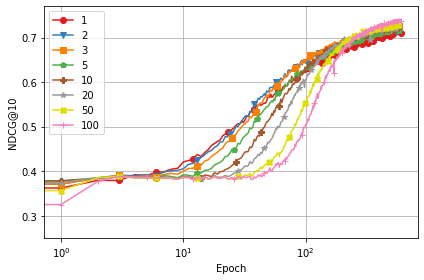

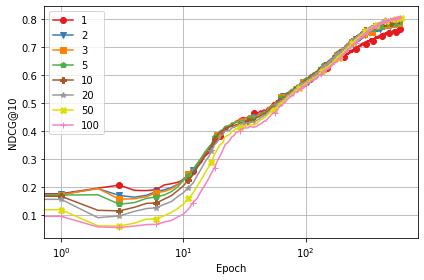

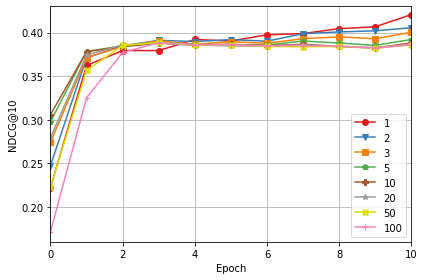

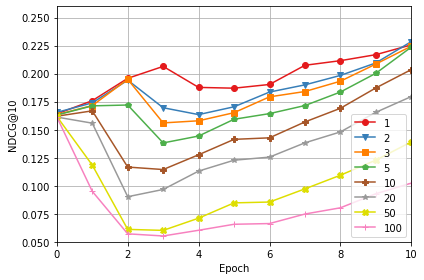

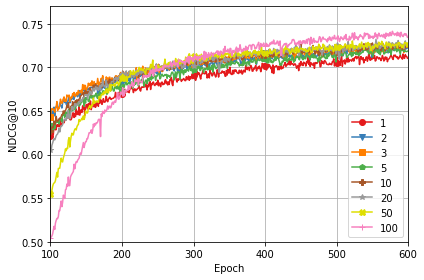

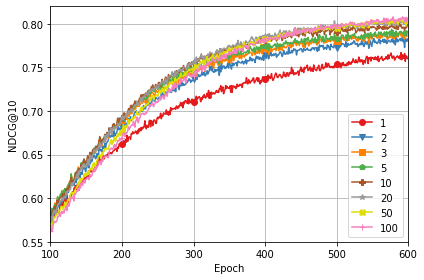

In [78]:
plot_name = "epochs_"+super_plot_name+"_GRU_SAS_"+subset_selection["data_params.name"]

#plot_instructions["subplots"] = {"nrows": 3, "ncols": 2, "figsize": (12,12)}
plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

plot_kwargs = {"markevery": 0.1}

ax_instructions.pop("set_xticks",None)
ax_instructions["legend"] = {"loc": "lower right"}
#ax_instructions["set_title"] = {"label": super_title}

label_convert_dict = {} #x:f"{x} positive item(s)" for x in [1,2,3,5,10,20,50,100]}

repeated_ax_instructions = [ax_instructions.copy() for _ in range(6)]
repeated_ax_instructions[0]["set_ylim"] = {"bottom":0.25}
repeated_ax_instructions[0]["legend"] = {"loc": "upper left"}
repeated_ax_instructions[1]["legend"] = {"loc": "upper left"}


repeated_ax_instructions[2]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[2]["set_ylim"] = {"bottom":0.16,"top":0.43}
repeated_ax_instructions[2].pop("set_xscale",None)
repeated_ax_instructions[3]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[3]["set_ylim"] = {"bottom":0.05,"top":0.26}
repeated_ax_instructions[3].pop("set_xscale",None)


repeated_ax_instructions[4]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[4]["set_ylim"] = {"bottom":0.5,"top":0.77}
repeated_ax_instructions[4].pop("set_xscale",None)
repeated_ax_instructions[5]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[5]["set_ylim"] = {"bottom":0.55,"top":0.82}
repeated_ax_instructions[5].pop("set_xscale",None)


repeated_plot_kwargs = [plot_kwargs.copy() for _ in range(6)]
repeated_plot_kwargs[2]["markevery"] = repeated_plot_kwargs[3]["markevery"] = 1
repeated_plot_kwargs[4]["markevery"] = repeated_plot_kwargs[5]["markevery"] = 100

label_a = ["(a)","(b)","(c)","(d)","(e)","(f)"]
label_b = ["GRU","SAS"]*3
label_c = [" - "+x if x !="" else x for x in ["","","start","start","end","end"]]
for i,(rep_ax_instr, rep_plot_kwargs) in enumerate(zip(repeated_ax_instructions,repeated_plot_kwargs)):
    rep_plot_instr = deepcopy(plot_instructions.copy())
    rep_plot_instr["savefig"]["fname"] = plot_instructions["savefig"]["fname"].split(".pdf")[0]+"_"+str(i)+".pdf"
    #rep_ax_instr["set_title"] = {"label": f"{label_a[i]} {label_b[i]}{label_c[i]}"}
    create_plot(rep_plot_instr, data=([gru_table,sas_table]*3)[i], label_columns=[main_x_column], x_column=x_column, y_column=y_column,
            ax_instructions = rep_ax_instr, label_convert_dict = label_convert_dict, plot_type="plot", plot_kwargs=rep_plot_kwargs)

#### ML-1M

In [79]:
subset_selection["data_params.name"] = "ml-1m"
subset_selection.pop("model.rec_model.name",None)

'GRU4Rec'

In [80]:
table = generate_table(subset_data(complete_data, subset_selection, subset_keep, merge_columns), rows_labels, column_labels, exp_name = "april_30", save_table=True)
table

,data_params.name,model.rec_model.name,data_params.collator_params.num_negatives.train,MAP_@10,MAP_@20,MAP_@5,NDCG_@10,NDCG_@20,NDCG_@5,Precision_@10,Precision_@20,Precision_@5,Recall_@10,Recall_@20,Recall_@5,test_FLOPS,test_flops,train_FLOPS,train_flops
0,ml-1m,GRU4Rec,1,0.1566,0.1062,0.2175,0.5594,0.5824,0.5239,0.0784,0.0437,0.1348,0.7838,0.8747,0.6740,4.940000e+12,1.240000e+12,4.920000e+12,2.224740e+15
1,ml-1m,GRU4Rec,2,0.1581,0.1069,0.2199,0.5636,0.5849,0.5294,0.0785,0.0434,0.1359,0.7846,0.8685,0.6795,4.900000e+12,1.240000e+12,4.890000e+12,2.224740e+15
2,ml-1m,GRU4Rec,3,0.1587,0.1072,0.2211,0.5659,0.5886,0.5296,0.0785,0.0437,0.1347,0.7846,0.8740,0.6735,4.850000e+12,1.240000e+12,4.880000e+12,2.224740e+15
3,ml-1m,GRU4Rec,5,0.1621,0.1090,0.2271,0.5749,0.5974,0.5440,0.0787,0.0438,0.1384,0.7874,0.8760,0.6922,4.870000e+12,1.240000e+12,4.870000e+12,2.224740e+15
4,ml-1m,GRU4Rec,10,0.1632,0.1096,0.2291,0.5794,0.6007,0.5474,0.0790,0.0437,0.1384,0.7901,0.8743,0.6921,4.870000e+12,1.240000e+12,4.860000e+12,2.224740e+15
5,ml-1m,GRU4Rec,20,0.1644,0.1103,0.2315,0.5834,0.6052,0.5513,0.0792,0.0439,0.1387,0.7924,0.8783,0.6934,4.900000e+12,1.240000e+12,4.840000e+12,2.224740e+15
6,ml-1m,GRU4Rec,50,0.1668,0.1116,0.2355,0.5908,0.6115,0.5600,0.0796,0.0439,0.1402,0.7957,0.8776,0.7010,4.870000e+12,1.240000e+12,4.810000e+12,2.224740e+15
7,ml-1m,GRU4Rec,100,0.1675,0.1120,0.2369,0.5927,0.6144,0.5614,0.0796,0.0440,0.1399,0.7955,0.8808,0.6993,4.890000e+12,1.240000e+12,4.810000e+12,2.224740e+15
8,ml-1m,SASRec,1,0.1643,0.1106,0.2297,0.5848,0.6046,0.5504,0.0806,0.0442,0.1401,0.8063,0.8839,0.7003,1.540000e+12,2.439200e+11,1.140000e+12,3.277400e+14
9,ml-1m,SASRec,2,0.1670,0.1121,0.2345,0.5925,0.6140,0.5615,0.0809,0.0447,0.1425,0.8086,0.8934,0.7127,1.540000e+12,2.439200e+11,1.140000e+12,3.277400e+14


In [81]:
x_column = main_x_column
x_label = main_x_label
y_column = "NDCG_@10"
y_label = y_column.replace("_", "")

ax_instructions = {"set_xscale": {"value": "log"},
                   "set_ylabel": {"ylabel": y_label},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "size":0}},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "width":0}},
                   "legend": {},
                   "grid":{}}

plot_instructions = {"subplots": {"nrows": 1, "ncols": 1, "figsize": (6,4)},
                    "tight_layout":{},
                    "savefig": {"fname": "plot.pdf"},
                    "show":{}}

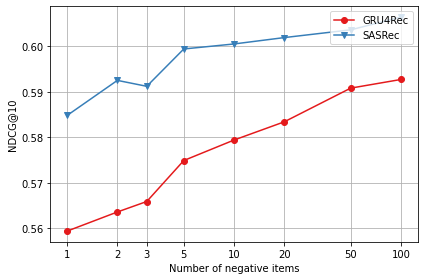

In [82]:
plot_name = super_plot_name+"_"+subset_selection["data_params.name"]

ax_instructions["set_xticks"] = {"ticks": table[x_column].unique().astype(int), "labels": table[x_column].unique().astype(int)}
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "upper right"}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)

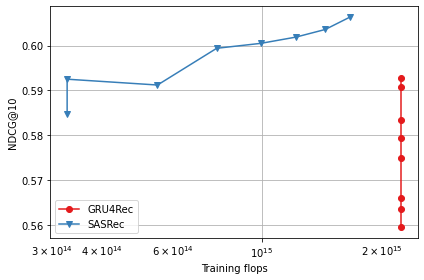

In [83]:
x_column = "train_flops"
x_label = "Training flops"
plot_name = super_plot_name+"_flops_"+subset_selection["data_params.name"]

ax_instructions.pop("set_xticks",None)
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "lower left"}
#ax_instructions["set_title"] = {"label": super_title}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)


In [84]:
x_column = "epoch"
x_label = "Epoch"
y_column = "val_NDCG_@10/dataloader_idx_1"
y_label = "NDCG@10"
ax_instructions["set_xlabel"] = {"xlabel": x_label}

##### SASRec

In [85]:
subset_selection["model.rec_model.name"] = "SASRec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

sas_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
sas_table = hotfix_table(sas_table, y_column) #HOTFIX
sas_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
34R6BMwhRKx65Rzl 0         0     47          NaN          NaN         NaN   
                 2         1     95          NaN          NaN         NaN   
                 4         2    143          NaN          NaN         NaN   
                 6         3    191          NaN          NaN         NaN   
                 8         4    239          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
sDM1mgQZrR9euJ02 1190    595  28607          NaN          NaN         NaN   
                 1192    596  28655          NaN          NaN         NaN   
                 1194    597  28703          NaN          NaN         NaN   
                 1196    598  28751          NaN          NaN         NaN   
                 1198    599  28799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
34R6BMwhRKx65Rzl 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
sDM1mgQZrR9euJ02 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
34R6BMwhRKx65Rzl 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
sDM1mgQZrR9euJ02 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
34R6BMwhRKx65Rzl 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
sDM1mgQZrR9euJ02 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
34R6BMwhRKx65Rzl 0              NaN         NaN             ml-1m   
                 2              NaN         NaN             ml-1m   
                 4              NaN         NaN             ml-1m   
           

In [86]:
subset_selection["model.rec_model.name"] = "GRU4Rec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)

gru_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
gru_table = hotfix_table(gru_table, y_column) #HOTFIX
gru_table

/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
EFzdH33nCeesv3WS 0         0     47          NaN          NaN         NaN   
                 2         1     95          NaN          NaN         NaN   
                 4         2    143          NaN          NaN         NaN   
                 6         3    191          NaN          NaN         NaN   
                 8         4    239          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
ugRwyHxlR97amttz 1190    595  28607          NaN          NaN         NaN   
                 1192    596  28655          NaN          NaN         NaN   
                 1194    597  28703          NaN          NaN         NaN   
                 1196    598  28751          NaN          NaN         NaN   
                 1198    599  28799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
EFzdH33nCeesv3WS 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
ugRwyHxlR97amttz 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
EFzdH33nCeesv3WS 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
ugRwyHxlR97amttz 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
EFzdH33nCeesv3WS 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
ugRwyHxlR97amttz 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
EFzdH33nCeesv3WS 0              NaN         NaN             ml-1m   
                 2              NaN         NaN             ml-1m   
                 4              NaN         NaN             ml-1m   
           

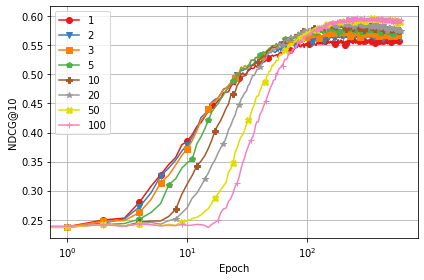

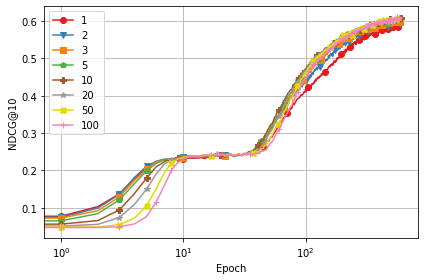

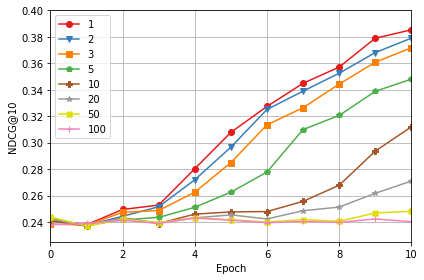

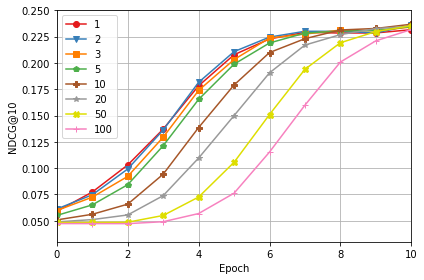

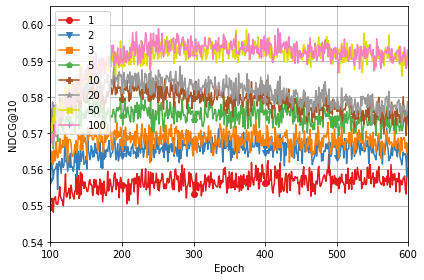

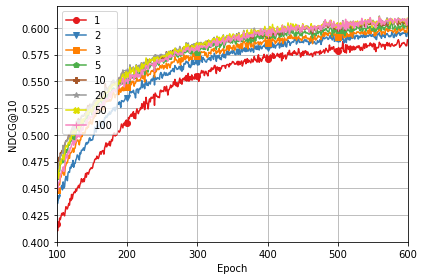

In [87]:
plot_name = "epochs_"+super_plot_name+"_GRU_SAS_"+subset_selection["data_params.name"]

#plot_instructions["subplots"] = {"nrows": 3, "ncols": 2, "figsize": (12,12)}
plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

plot_kwargs = {"markevery": 0.1}

ax_instructions.pop("set_xticks",None)
ax_instructions["legend"] = {"loc": "upper left"}
#ax_instructions["set_title"] = {"label": super_title}

label_convert_dict = {} #x:f"{x} positive item(s)" for x in [1,2,3,5,10,20,50,100]}

repeated_ax_instructions = [ax_instructions.copy() for _ in range(6)]
repeated_ax_instructions[2]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[2]["set_ylim"] = {"bottom":0.225,"top":0.4}
repeated_ax_instructions[2].pop("set_xscale",None)
repeated_ax_instructions[3]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[3]["set_ylim"] = {"bottom":0.03,"top":0.25}
repeated_ax_instructions[3].pop("set_xscale",None)


repeated_ax_instructions[4]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[4]["set_ylim"] = {"bottom":0.54,"top":0.605}
repeated_ax_instructions[4].pop("set_xscale",None)
repeated_ax_instructions[5]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[5]["set_ylim"] = {"bottom":0.4,"top":0.62}
repeated_ax_instructions[5].pop("set_xscale",None)


repeated_plot_kwargs = [plot_kwargs.copy() for _ in range(6)]
repeated_plot_kwargs[2]["markevery"] = repeated_plot_kwargs[3]["markevery"] = 1
repeated_plot_kwargs[4]["markevery"] = repeated_plot_kwargs[5]["markevery"] = 100

label_a = ["(a)","(b)","(c)","(d)","(e)","(f)"]
label_b = ["GRU","SAS"]*3
label_c = [" - "+x if x !="" else x for x in ["","","start","start","end","end"]]
for i,(rep_ax_instr, rep_plot_kwargs) in enumerate(zip(repeated_ax_instructions,repeated_plot_kwargs)):
    rep_plot_instr = deepcopy(plot_instructions.copy())
    rep_plot_instr["savefig"]["fname"] = plot_instructions["savefig"]["fname"].split(".pdf")[0]+"_"+str(i)+".pdf"
    #rep_ax_instr["set_title"] = {"label": f"{label_a[i]} {label_b[i]}{label_c[i]}"}
    create_plot(rep_plot_instr, data=([gru_table,sas_table]*3)[i], label_columns=[main_x_column], x_column=x_column, y_column=y_column,
            ax_instructions = rep_ax_instr, label_convert_dict = label_convert_dict, plot_type="plot", plot_kwargs=rep_plot_kwargs)

### Num positives/negatives

In [88]:
main_x_column = "num_pos_neg"
main_x_label = "Number of positive/negative items"
super_plot_name = "pos_neg_NDCG@10"
super_title = "Performance with varying number of positive/negative items"

In [89]:
rows_label_to_add = [main_x_column]
rows_labels = main_rows_labels + rows_label_to_add

subset_selection = {}
merge_columns = {"num_pos_neg":["data_params.collator_params.simultaneous_lookforward",
                                "data_params.collator_params.num_negatives.train"]}

In [90]:
def subset_to_equal_pos_neg(table):
    def eq_pos_neg(x):
        p,n = x.split("_")
        if p==n: return True
        else: return False
    def comb_pos_neg(x):
        p,n = x.split("_")
        return int(p)
    table = table.loc[table["num_pos_neg"].apply(eq_pos_neg)]
    table["num_pos_neg"] = table["num_pos_neg"].apply(comb_pos_neg)
    # sort by number of positive items
    table = table.sort_values("num_pos_neg")
    return table

#### Amazon-beauty

In [91]:
subset_selection["data_params.name"] = "amazon_beauty"
subset_selection.pop("model.rec_model.name",None)

In [92]:
table = generate_table(subset_data(complete_data, subset_selection, subset_keep, merge_columns), rows_labels, column_labels, exp_name = "april_30", save_table=True)
table = subset_to_equal_pos_neg(table)
table

/tmp/ipykernel_612398/2013779122.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_data[col_name] = subset_data.loc[:,cols].apply(lambda row: '_'.join([str(x) for x in row if pd.notnull(x)]), axis=1)
/tmp/ipykernel_612398/688034775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table["num_pos_neg"] = table["num_pos_neg"].apply(comb_pos_neg)


,data_params.name,model.rec_model.name,num_pos_neg,MAP_@10,MAP_@20,MAP_@5,NDCG_@10,NDCG_@20,NDCG_@5,Precision_@10,Precision_@20,Precision_@5,Recall_@10,Recall_@20,Recall_@5,test_FLOPS,test_flops,train_FLOPS,train_flops
4,amazon_beauty,GRU4Rec,1,0.1865,0.1165,0.2855,0.6387,0.6457,0.6340,0.0683,0.0356,0.1338,0.6829,0.7111,0.6688,3.600000e+12,1.080500e+11,3.820000e+12,1.945400e+14
26,amazon_beauty,SASRec,1,0.1246,0.0858,0.1682,0.4638,0.4744,0.4081,0.0677,0.0359,0.1019,0.6774,0.7190,0.5094,1.420000e+12,5.145000e+10,1.140000e+12,6.914000e+13
15,amazon_beauty,GRU4Rec,2,0.1140,0.0796,0.1531,0.4303,0.4449,0.3704,0.0641,0.0349,0.0917,0.6405,0.6978,0.4584,3.680000e+12,1.080500e+11,3.860000e+12,1.945400e+14
37,amazon_beauty,SASRec,2,0.1920,0.1196,0.2948,0.6568,0.6608,0.6534,0.0697,0.0356,0.1372,0.6970,0.7127,0.6860,1.490000e+12,5.145000e+10,1.170000e+12,6.914000e+13
17,amazon_beauty,GRU4Rec,3,0.1262,0.0858,0.1717,0.4556,0.4687,0.4290,0.0648,0.0349,0.1135,0.6476,0.6986,0.5675,3.670000e+12,1.080500e+11,3.900000e+12,1.945400e+14
39,amazon_beauty,SASRec,3,0.0950,0.0655,0.1413,0.3357,0.4064,0.3193,0.0403,0.0344,0.0702,0.4027,0.6876,0.3509,2.340000e+12,7.754000e+10,1.980000e+12,1.161200e+14
21,amazon_beauty,GRU4Rec,5,0.1322,0.0885,0.1824,0.4694,0.4797,0.4501,0.0648,0.0344,0.1181,0.6476,0.6876,0.5903,3.710000e+12,1.080500e+11,3.900000e+12,1.945400e+14
43,amazon_beauty,SASRec,5,0.1079,0.0766,0.1509,0.4108,0.4396,0.3473,0.0594,0.0351,0.0790,0.5942,0.7025,0.3948,3.240000e+12,1.036300e+11,2.770000e+12,1.630900e+14
3,amazon_beauty,GRU4Rec,10,0.1261,0.0851,0.1728,0.4528,0.4644,0.4245,0.0634,0.0340,0.1100,0.6342,0.6805,0.5502,3.500000e+12,1.080500e+11,3.890000e+12,1.945400e+14
25,amazon_beauty,SASRec,10,0.1871,0.1166,0.2874,0.6381,0.6456,0.6371,0.0674,0.0352,0.1342,0.6743,0.7041,0.6711,3.650000e+12,1.297200e+11,3.560000e+12,2.100700e+14


In [93]:
y_column = "NDCG_@10"
y_label = y_column.replace("_", "")

ax_instructions = {"set_xscale": {"value": "log"},
                   "set_ylabel": {"ylabel": y_label},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "size":0}},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "width":0}},
                   "legend": {},
                   "grid":{}}

plot_instructions = {"subplots": {"nrows": 1, "ncols": 1, "figsize": (6,4)},
                    "tight_layout":{},
                    "savefig": {"fname": "plot.pdf"},
                    "show":{}}

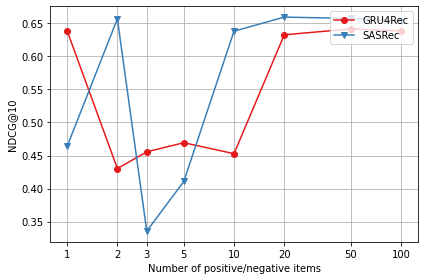

In [94]:
x_column = main_x_column
x_label = main_x_label
plot_name = super_plot_name+"_"+subset_selection["data_params.name"]

ax_instructions["set_xticks"] = {"ticks": table[x_column].unique().astype(int), "labels": table[x_column].unique().astype(int)}
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "upper right"}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)

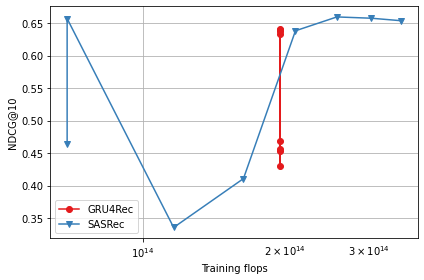

In [95]:
x_column = "train_flops"
x_label = "Training flops"
plot_name = super_plot_name+"_flops_"+subset_selection["data_params.name"]

ax_instructions.pop("set_xticks",None)
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "lower left"}
#ax_instructions["set_title"] = {"label": super_title}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)


In [96]:
x_column = "epoch"
x_label = "Epoch"
y_column = "val_NDCG_@10/dataloader_idx_1"
y_label = "NDCG@10"
ax_instructions["set_xlabel"] = {"xlabel": x_label}

##### SASRec

In [97]:
subset_selection["model.rec_model.name"] = "SASRec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)
epoch_table = subset_to_equal_pos_neg(epoch_table)

sas_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
sas_table = hotfix_table(sas_table, y_column) #HOTFIX
sas_table

/tmp/ipykernel_612398/688034775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table["num_pos_neg"] = table["num_pos_neg"].apply(comb_pos_neg)
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

epoch  step  test_F1_@10  test_F1_@20  test_F1_@5  \
rLQi99STMupgaPTC 0         0     9          NaN          NaN         NaN   
                 2         1    19          NaN          NaN         NaN   
                 4         2    29          NaN          NaN         NaN   
                 6         3    39          NaN          NaN         NaN   
                 8         4    49          NaN          NaN         NaN   
...                      ...   ...          ...          ...         ...   
neKdfMfxPYRokYSC 1190    595  5959          NaN          NaN         NaN   
                 1192    596  5969          NaN          NaN         NaN   
                 1194    597  5979          NaN          NaN         NaN   
                 1196    598  5989          NaN          NaN         NaN   
                 1198    599  5999          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
rLQi99STMupgaPTC 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
neKdfMfxPYRokYSC 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
rLQi99STMupgaPTC 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
neKdfMfxPYRokYSC 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
rLQi99STMupgaPTC 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
neKdfMfxPYRokYSC 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
rLQi99STMupgaPTC 0              NaN         NaN     amazon_beauty   
                 2              NaN         NaN     amazon_beauty   
                 4              NaN         NaN     amazon_beauty   
                 6     

In [98]:
subset_selection["model.rec_model.name"] = "GRU4Rec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)
epoch_table = subset_to_equal_pos_neg(epoch_table)

gru_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
gru_table = hotfix_table(gru_table, y_column) #HOTFIX
gru_table

/tmp/ipykernel_612398/688034775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table["num_pos_neg"] = table["num_pos_neg"].apply(comb_pos_neg)
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

epoch  step  test_F1_@10  test_F1_@20  test_F1_@5  \
w5EK0LMa3l9y8HDZ 0         0     9          NaN          NaN         NaN   
                 2         1    19          NaN          NaN         NaN   
                 4         2    29          NaN          NaN         NaN   
                 6         3    39          NaN          NaN         NaN   
                 8         4    49          NaN          NaN         NaN   
...                      ...   ...          ...          ...         ...   
cOVYeBn4wkIAMbm6 1190    595  5959          NaN          NaN         NaN   
                 1192    596  5969          NaN          NaN         NaN   
                 1194    597  5979          NaN          NaN         NaN   
                 1196    598  5989          NaN          NaN         NaN   
                 1198    599  5999          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
w5EK0LMa3l9y8HDZ 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
cOVYeBn4wkIAMbm6 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
w5EK0LMa3l9y8HDZ 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
cOVYeBn4wkIAMbm6 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
w5EK0LMa3l9y8HDZ 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
cOVYeBn4wkIAMbm6 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
w5EK0LMa3l9y8HDZ 0              NaN         NaN     amazon_beauty   
                 2              NaN         NaN     amazon_beauty   
                 4              NaN         NaN     amazon_beauty   
                 6     

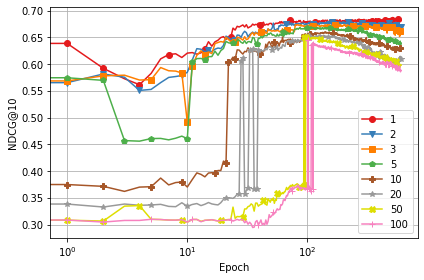

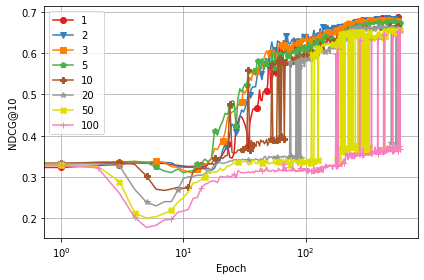

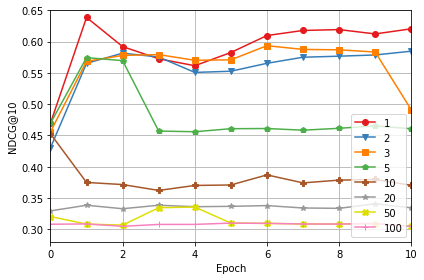

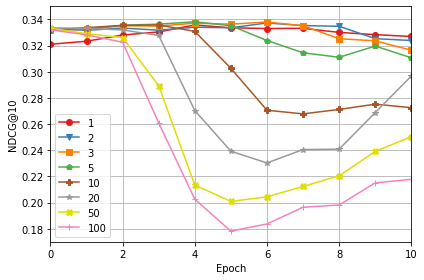

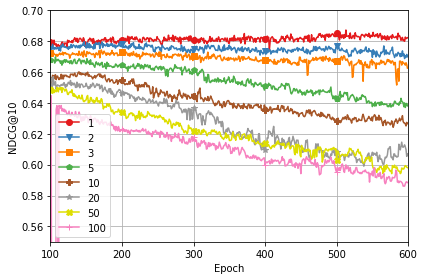

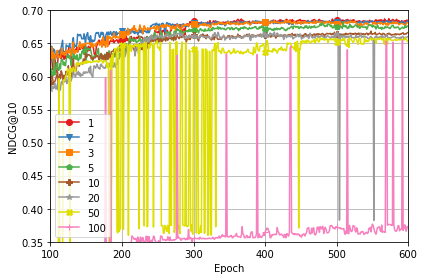

In [99]:
plot_name = "epochs_"+super_plot_name+"_GRU_SAS_"+subset_selection["data_params.name"]

#plot_instructions["subplots"] = {"nrows": 3, "ncols": 2, "figsize": (12,12)}
plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

plot_kwargs = {"markevery": 0.1}

ax_instructions.pop("set_xticks",None)
ax_instructions["legend"] = {"loc": "lower right"}
#ax_instructions["set_title"] = {"label": super_title}

label_convert_dict = {} #x:f"{x} positive item(s)" for x in [1,2,3,5,10,20,50,100]}

repeated_ax_instructions = [ax_instructions.copy() for _ in range(6)]
#repeated_ax_instructions[0]["set_ylim"] = {"bottom":0.525}
repeated_ax_instructions[1]["legend"] = {"loc": "upper left"}

repeated_ax_instructions[2]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[2]["set_ylim"] = {"bottom":0.28,"top":0.65}
repeated_ax_instructions[2].pop("set_xscale",None)
repeated_ax_instructions[3]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[3]["set_ylim"] = {"bottom":0.17,"top":0.35}
repeated_ax_instructions[3]["legend"] = {"loc": "lower left"}
repeated_ax_instructions[3].pop("set_xscale",None)


repeated_ax_instructions[4]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[4]["set_ylim"] = {"bottom":0.55,"top":0.7}
repeated_ax_instructions[4].pop("set_xscale",None)
repeated_ax_instructions[4]["legend"] = {"loc": "lower left"}
repeated_ax_instructions[5]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[5]["set_ylim"] = {"bottom":0.35,"top":0.7}
repeated_ax_instructions[5].pop("set_xscale",None)
repeated_ax_instructions[5]["legend"] = {"loc": "lower left"}


repeated_plot_kwargs = [plot_kwargs.copy() for _ in range(6)]
repeated_plot_kwargs[2]["markevery"] = repeated_plot_kwargs[3]["markevery"] = 1
repeated_plot_kwargs[4]["markevery"] = repeated_plot_kwargs[5]["markevery"] = 100

label_a = ["(a)","(b)","(c)","(d)","(e)","(f)"]
label_b = ["GRU","SAS"]*3
label_c = [" - "+x if x !="" else x for x in ["","","start","start","end","end"]]
for i,(rep_ax_instr, rep_plot_kwargs) in enumerate(zip(repeated_ax_instructions,repeated_plot_kwargs)):
    rep_plot_instr = deepcopy(plot_instructions.copy())
    rep_plot_instr["savefig"]["fname"] = plot_instructions["savefig"]["fname"].split(".pdf")[0]+"_"+str(i)+".pdf"
    #rep_ax_instr["set_title"] = {"label": f"{label_a[i]} {label_b[i]}{label_c[i]}"}
    create_plot(rep_plot_instr, data=([gru_table,sas_table]*3)[i], label_columns=[main_x_column], x_column=x_column, y_column=y_column,
            ax_instructions = rep_ax_instr, label_convert_dict = label_convert_dict, plot_type="plot", plot_kwargs=rep_plot_kwargs)

#### Foursquare TKY

In [100]:
subset_selection["data_params.name"] = "foursquare-tky"
subset_selection.pop("model.rec_model.name",None)

'GRU4Rec'

In [101]:
table = generate_table(subset_data(complete_data, subset_selection, subset_keep, merge_columns), rows_labels, column_labels, exp_name = "april_30", save_table=True)
table = subset_to_equal_pos_neg(table)
table

/tmp/ipykernel_612398/2013779122.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_data[col_name] = subset_data.loc[:,cols].apply(lambda row: '_'.join([str(x) for x in row if pd.notnull(x)]), axis=1)
/tmp/ipykernel_612398/688034775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table["num_pos_neg"] = table["num_pos_neg"].apply(comb_pos_neg)


,data_params.name,model.rec_model.name,num_pos_neg,MAP_@10,MAP_@20,MAP_@5,NDCG_@10,NDCG_@20,NDCG_@5,Precision_@10,Precision_@20,Precision_@5,Recall_@10,Recall_@20,Recall_@5,test_FLOPS,test_flops,train_FLOPS,train_flops
4,foursquare-tky,GRU4Rec,1,0.2013,0.1295,0.2983,0.7022,0.7158,0.6798,0.0834,0.0444,0.1530,0.8338,0.8875,0.7649,5.430000e+12,1.850000e+12,5.380000e+12,3.330330e+15
26,foursquare-tky,SASRec,1,0.2193,0.1394,0.3289,0.7600,0.7718,0.7415,0.0866,0.0456,0.1620,0.8657,0.9128,0.8099,7.140000e+12,4.682900e+11,7.090000e+12,8.007500e+14
15,foursquare-tky,GRU4Rec,2,0.1872,0.1225,0.2717,0.6565,0.6729,0.6304,0.0826,0.0446,0.1492,0.8264,0.8914,0.7462,5.530000e+12,1.850000e+12,5.500000e+12,3.330330e+15
37,foursquare-tky,SASRec,2,0.2164,0.1376,0.3248,0.7483,0.7613,0.7348,0.0852,0.0452,0.1621,0.8522,0.9032,0.8103,7.130000e+12,4.213200e+11,6.320000e+12,7.162100e+14
17,foursquare-tky,GRU4Rec,3,0.1760,0.1161,0.2526,0.6203,0.6380,0.5940,0.0800,0.0435,0.1438,0.8003,0.8700,0.7191,5.500000e+12,1.850000e+12,5.500000e+12,3.330330e+15
39,foursquare-tky,SASRec,3,0.2160,0.1371,0.3247,0.7455,0.7590,0.7326,0.0843,0.0449,0.1608,0.8434,0.8971,0.8042,7.620000e+12,4.682900e+11,7.000000e+12,8.007500e+14
21,foursquare-tky,GRU4Rec,5,0.1644,0.1096,0.2325,0.5832,0.6004,0.5522,0.0781,0.0425,0.1372,0.7811,0.8491,0.6860,5.540000e+12,1.850000e+12,5.500000e+12,3.330330e+15
43,foursquare-tky,SASRec,5,0.2091,0.1332,0.3126,0.7228,0.7353,0.7102,0.0831,0.0441,0.1586,0.8312,0.8814,0.7928,8.200000e+12,5.152500e+11,7.560000e+12,8.852900e+14
3,foursquare-tky,GRU4Rec,10,0.1797,0.1179,0.2589,0.6309,0.6424,0.6042,0.0807,0.0426,0.1451,0.8068,0.8513,0.7253,5.490000e+12,1.850000e+12,5.500000e+12,3.330330e+15
25,foursquare-tky,SASRec,10,0.2028,0.1290,0.3019,0.6997,0.7092,0.6894,0.0813,0.0426,0.1564,0.8129,0.8526,0.7819,9.310000e+12,5.622100e+11,7.880000e+12,9.698300e+14


In [102]:
y_column = "NDCG_@10"
y_label = y_column.replace("_", "")

ax_instructions = {"set_xscale": {"value": "log"},
                   "set_ylabel": {"ylabel": y_label},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "size":0}},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "width":0}},
                   "legend": {},
                   "grid":{}}

plot_instructions = {"subplots": {"nrows": 1, "ncols": 1, "figsize": (6,4)},
                    "tight_layout":{},
                    "savefig": {"fname": "plot.pdf"},
                    "show":{}}

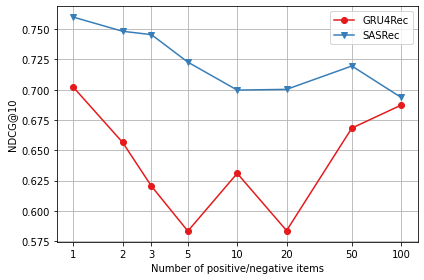

In [103]:
x_column = main_x_column
x_label = main_x_label
plot_name = super_plot_name+"_"+subset_selection["data_params.name"]

ax_instructions["set_xticks"] = {"ticks": table[x_column].unique().astype(int), "labels": table[x_column].unique().astype(int)}
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "upper right"}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)

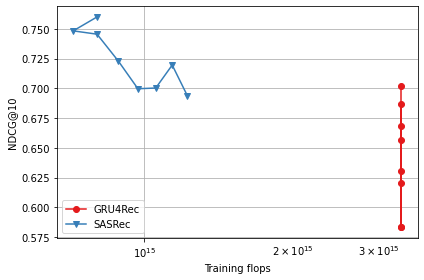

In [104]:
x_column = "train_flops"
x_label = "Training flops"
plot_name = super_plot_name+"_flops_"+subset_selection["data_params.name"]

ax_instructions.pop("set_xticks",None)
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "lower left"}
#ax_instructions["set_title"] = {"label": super_title}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)


In [105]:
x_column = "epoch"
x_label = "Epoch"
y_column = "val_NDCG_@10/dataloader_idx_1"
y_label = "NDCG@10"
ax_instructions["set_xlabel"] = {"xlabel": x_label}

##### SASRec

In [106]:
subset_selection["model.rec_model.name"] = "SASRec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)
epoch_table = subset_to_equal_pos_neg(epoch_table)

sas_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
sas_table = hotfix_table(sas_table, y_column) #HOTFIX
sas_table

/tmp/ipykernel_612398/688034775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table["num_pos_neg"] = table["num_pos_neg"].apply(comb_pos_neg)
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
E1paMI9iVZOltH16 0         0     17          NaN          NaN         NaN   
                 2         1     35          NaN          NaN         NaN   
                 4         2     53          NaN          NaN         NaN   
                 6         3     71          NaN          NaN         NaN   
                 8         4     89          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
aNaNhFsMzVrkupDg 1190    595  10727          NaN          NaN         NaN   
                 1192    596  10745          NaN          NaN         NaN   
                 1194    597  10763          NaN          NaN         NaN   
                 1196    598  10781          NaN          NaN         NaN   
                 1198    599  10799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
E1paMI9iVZOltH16 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
aNaNhFsMzVrkupDg 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
E1paMI9iVZOltH16 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
aNaNhFsMzVrkupDg 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
E1paMI9iVZOltH16 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
aNaNhFsMzVrkupDg 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
E1paMI9iVZOltH16 0              NaN         NaN    foursquare-tky   
                 2              NaN         NaN    foursquare-tky   
                 4              NaN         NaN    foursquare-tky   
           

In [107]:
subset_selection["model.rec_model.name"] = "GRU4Rec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)
epoch_table = subset_to_equal_pos_neg(epoch_table)

gru_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
gru_table = hotfix_table(gru_table, y_column) #HOTFIX
gru_table

/tmp/ipykernel_612398/688034775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table["num_pos_neg"] = table["num_pos_neg"].apply(comb_pos_neg)
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
xJJ9K44SQ7woxFse 0         0     17          NaN          NaN         NaN   
                 2         1     35          NaN          NaN         NaN   
                 4         2     53          NaN          NaN         NaN   
                 6         3     71          NaN          NaN         NaN   
                 8         4     89          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
CxGH5Ykbo1XwXocM 1190    595  10727          NaN          NaN         NaN   
                 1192    596  10745          NaN          NaN         NaN   
                 1194    597  10763          NaN          NaN         NaN   
                 1196    598  10781          NaN          NaN         NaN   
                 1198    599  10799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
xJJ9K44SQ7woxFse 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
CxGH5Ykbo1XwXocM 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
xJJ9K44SQ7woxFse 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
CxGH5Ykbo1XwXocM 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
xJJ9K44SQ7woxFse 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
CxGH5Ykbo1XwXocM 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
xJJ9K44SQ7woxFse 0              NaN         NaN    foursquare-tky   
                 2              NaN         NaN    foursquare-tky   
                 4              NaN         NaN    foursquare-tky   
           

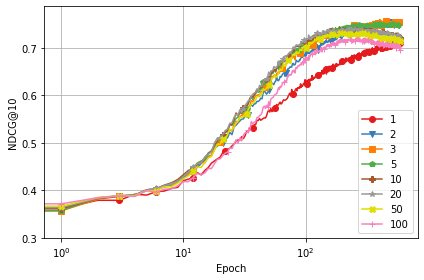

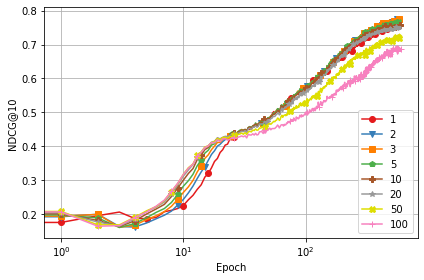

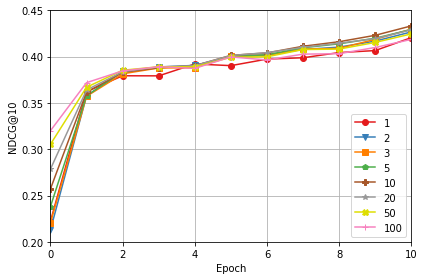

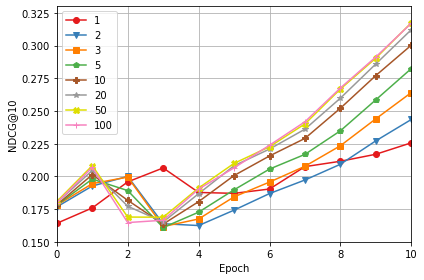

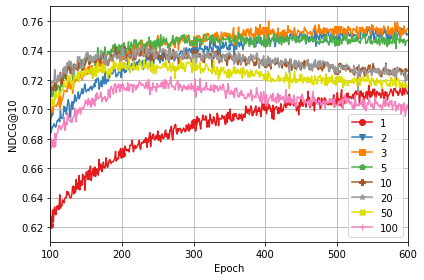

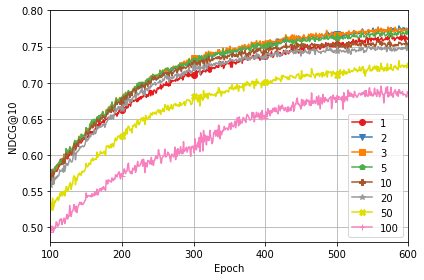

In [108]:
plot_name = "epochs_"+super_plot_name+"_GRU_SAS_"+subset_selection["data_params.name"]

#plot_instructions["subplots"] = {"nrows": 3, "ncols": 2, "figsize": (12,12)}
plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

plot_kwargs = {"markevery": 0.1}

ax_instructions.pop("set_xticks",None)
ax_instructions["legend"] = {"loc": "lower right"}
#ax_instructions["set_title"] = {"label": super_title}

label_convert_dict = {} #x:f"{x} positive item(s)" for x in [1,2,3,5,10,20,50,100]}

repeated_ax_instructions = [ax_instructions.copy() for _ in range(6)]
repeated_ax_instructions[0]["set_ylim"] = {"bottom":0.3}


repeated_ax_instructions[2]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[2]["set_ylim"] = {"bottom":0.2,"top":0.45}
repeated_ax_instructions[2].pop("set_xscale",None)
repeated_ax_instructions[3]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[3]["set_ylim"] = {"bottom":0.15,"top":0.33}
repeated_ax_instructions[3].pop("set_xscale",None)
repeated_ax_instructions[3]["legend"] = {"loc": "upper left"}


repeated_ax_instructions[4]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[4]["set_ylim"] = {"bottom":0.61,"top":0.77}
repeated_ax_instructions[4].pop("set_xscale",None)
repeated_ax_instructions[5]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[5]["set_ylim"] = {"bottom":0.48,"top":0.8}
repeated_ax_instructions[5].pop("set_xscale",None)


repeated_plot_kwargs = [plot_kwargs.copy() for _ in range(6)]
repeated_plot_kwargs[2]["markevery"] = repeated_plot_kwargs[3]["markevery"] = 1
repeated_plot_kwargs[4]["markevery"] = repeated_plot_kwargs[5]["markevery"] = 100

label_a = ["(a)","(b)","(c)","(d)","(e)","(f)"]
label_b = ["GRU","SAS"]*3
label_c = [" - "+x if x !="" else x for x in ["","","start","start","end","end"]]
for i,(rep_ax_instr, rep_plot_kwargs) in enumerate(zip(repeated_ax_instructions,repeated_plot_kwargs)):
    rep_plot_instr = deepcopy(plot_instructions.copy())
    rep_plot_instr["savefig"]["fname"] = plot_instructions["savefig"]["fname"].split(".pdf")[0]+"_"+str(i)+".pdf"
    #rep_ax_instr["set_title"] = {"label": f"{label_a[i]} {label_b[i]}{label_c[i]}"}
    create_plot(rep_plot_instr, data=([gru_table,sas_table]*3)[i], label_columns=[main_x_column], x_column=x_column, y_column=y_column,
            ax_instructions = rep_ax_instr, label_convert_dict = label_convert_dict, plot_type="plot", plot_kwargs=rep_plot_kwargs)

#### ML-1M

In [109]:
subset_selection["data_params.name"] = "ml-1m"
subset_selection.pop("model.rec_model.name",None)

'GRU4Rec'

In [110]:
table = generate_table(subset_data(complete_data, subset_selection, subset_keep, merge_columns), rows_labels, column_labels, exp_name = "april_30", save_table=True)
table = subset_to_equal_pos_neg(table)
table

/tmp/ipykernel_612398/2013779122.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_data[col_name] = subset_data.loc[:,cols].apply(lambda row: '_'.join([str(x) for x in row if pd.notnull(x)]), axis=1)
/tmp/ipykernel_612398/688034775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table["num_pos_neg"] = table["num_pos_neg"].apply(comb_pos_neg)


,data_params.name,model.rec_model.name,num_pos_neg,MAP_@10,MAP_@20,MAP_@5,NDCG_@10,NDCG_@20,NDCG_@5,Precision_@10,Precision_@20,Precision_@5,Recall_@10,Recall_@20,Recall_@5,test_FLOPS,test_flops,train_FLOPS,train_flops
4,ml-1m,GRU4Rec,1,0.1566,0.1062,0.2175,0.5594,0.5824,0.5239,0.0784,0.0437,0.1348,0.7838,0.8747,0.6740,4.940000e+12,1.240000e+12,4.920000e+12,2.224740e+15
26,ml-1m,SASRec,1,0.1643,0.1106,0.2297,0.5848,0.6046,0.5504,0.0806,0.0442,0.1401,0.8063,0.8839,0.7003,1.540000e+12,2.439200e+11,1.140000e+12,3.277400e+14
15,ml-1m,GRU4Rec,2,0.1508,0.1029,0.2074,0.5403,0.5641,0.5041,0.0771,0.0433,0.1320,0.7710,0.8651,0.6599,4.890000e+12,1.240000e+12,4.910000e+12,2.224740e+15
37,ml-1m,SASRec,2,0.1608,0.1086,0.2238,0.5724,0.5936,0.5400,0.0795,0.0439,0.1391,0.7954,0.8790,0.6957,2.250000e+12,3.676200e+11,1.930000e+12,5.504100e+14
17,ml-1m,GRU4Rec,3,0.1511,0.1029,0.2087,0.5402,0.5627,0.5060,0.0765,0.0427,0.1319,0.7649,0.8535,0.6596,4.900000e+12,1.240000e+12,4.900000e+12,2.224740e+15
39,ml-1m,SASRec,3,0.1590,0.1074,0.2210,0.5664,0.5871,0.5329,0.0789,0.0436,0.1372,0.7887,0.8710,0.6861,2.980000e+12,4.913200e+11,2.580000e+12,7.730800e+14
21,ml-1m,GRU4Rec,5,0.1502,0.1023,0.2061,0.5368,0.5577,0.5020,0.0768,0.0426,0.1324,0.7682,0.8512,0.6618,4.930000e+12,1.240000e+12,4.880000e+12,2.224740e+15
43,ml-1m,SASRec,5,0.1548,0.1048,0.2151,0.5488,0.5734,0.5200,0.0765,0.0431,0.1353,0.7649,0.8623,0.6763,3.730000e+12,6.150200e+11,3.210000e+12,9.957500e+14
3,ml-1m,GRU4Rec,10,0.1364,0.0947,0.1834,0.4949,0.5162,0.4539,0.0741,0.0412,0.1229,0.7407,0.8237,0.6144,4.900000e+12,1.240000e+12,4.840000e+12,2.224740e+15
25,ml-1m,SASRec,10,0.0995,0.0731,0.1249,0.3763,0.4025,0.3247,0.0635,0.0368,0.0951,0.6346,0.7366,0.4755,4.540000e+12,7.387200e+11,3.650000e+12,1.218420e+15


In [111]:
x_column = main_x_column
x_label = main_x_label
y_column = "NDCG_@10"
y_label = y_column.replace("_", "")

ax_instructions = {"set_xscale": {"value": "log"},
                   "set_ylabel": {"ylabel": y_label},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "size":0}},
                   "get_xaxis": {"__kwargs__":{},
                                 "set_tick_params": {"which":"minor", "width":0}},
                   "legend": {},
                   "grid":{}}

plot_instructions = {"subplots": {"nrows": 1, "ncols": 1, "figsize": (6,4)},
                    "tight_layout":{},
                    "savefig": {"fname": "plot.pdf"},
                    "show":{}}

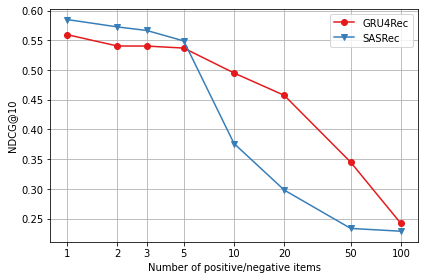

In [112]:
plot_name = super_plot_name+"_"+subset_selection["data_params.name"]

ax_instructions["set_xticks"] = {"ticks": table[x_column].unique().astype(int), "labels": table[x_column].unique().astype(int)}
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "upper right"}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)

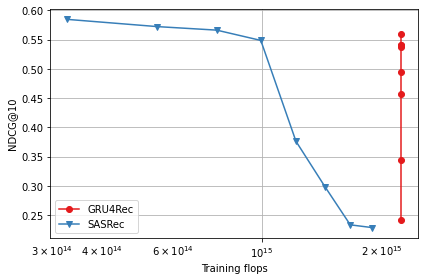

In [113]:
x_column = "train_flops"
x_label = "Training flops"
plot_name = super_plot_name+"_flops_"+subset_selection["data_params.name"]

ax_instructions.pop("set_xticks",None)
ax_instructions["set_xlabel"] = {"xlabel": x_label}
ax_instructions["legend"] = {"loc": "lower left"}
#ax_instructions["set_title"] = {"label": super_title}

plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

label_convert_dict = {}

create_plot(plot_instructions, data=table, label_columns=["model.rec_model.name"], x_column=x_column, y_column=y_column,
            ax_instructions = ax_instructions, label_convert_dict = label_convert_dict)


In [114]:
x_column = "epoch"
x_label = "Epoch"
y_column = "val_NDCG_@10/dataloader_idx_1"
y_label = "NDCG@10"
ax_instructions["set_xlabel"] = {"xlabel": x_label}

##### SASRec

In [115]:
subset_selection["model.rec_model.name"] = "SASRec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)
epoch_table = subset_to_equal_pos_neg(epoch_table)

sas_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
sas_table = hotfix_table(sas_table, y_column) #HOTFIX
sas_table

/tmp/ipykernel_612398/688034775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table["num_pos_neg"] = table["num_pos_neg"].apply(comb_pos_neg)
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
sDM1mgQZrR9euJ02 0         0     47          NaN          NaN         NaN   
                 2         1     95          NaN          NaN         NaN   
                 4         2    143          NaN          NaN         NaN   
                 6         3    191          NaN          NaN         NaN   
                 8         4    239          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
FwVv6UoeLnV2s3vp 1190    595  28607          NaN          NaN         NaN   
                 1192    596  28655          NaN          NaN         NaN   
                 1194    597  28703          NaN          NaN         NaN   
                 1196    598  28751          NaN          NaN         NaN   
                 1198    599  28799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
sDM1mgQZrR9euJ02 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
FwVv6UoeLnV2s3vp 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
sDM1mgQZrR9euJ02 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
FwVv6UoeLnV2s3vp 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
sDM1mgQZrR9euJ02 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
FwVv6UoeLnV2s3vp 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
sDM1mgQZrR9euJ02 0              NaN         NaN             ml-1m   
                 2              NaN         NaN             ml-1m   
                 4              NaN         NaN             ml-1m   
           

In [116]:
subset_selection["model.rec_model.name"] = "GRU4Rec"
epoch_table = subset_data(complete_data, subset_selection, subset_keep, merge_columns)
epoch_table = subset_to_equal_pos_neg(epoch_table)

gru_table = merge_epoch_data(metrics_per_epoch, epoch_table, rows_labels)
gru_table = hotfix_table(gru_table, y_column) #HOTFIX
gru_table

/tmp/ipykernel_612398/688034775.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table["num_pos_neg"] = table["num_pos_neg"].apply(comb_pos_neg)
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_metrics[exp_id].loc[:,col] = table.loc[exp_id,col]
/tmp/ipykernel_612398/176174044.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

epoch   step  test_F1_@10  test_F1_@20  test_F1_@5  \
U3P9JKzDEsgUnihq 0         0     47          NaN          NaN         NaN   
                 2         1     95          NaN          NaN         NaN   
                 4         2    143          NaN          NaN         NaN   
                 6         3    191          NaN          NaN         NaN   
                 8         4    239          NaN          NaN         NaN   
...                      ...    ...          ...          ...         ...   
ggnxNeFGI1T1HkTF 1190    595  28607          NaN          NaN         NaN   
                 1192    596  28655          NaN          NaN         NaN   
                 1194    597  28703          NaN          NaN         NaN   
                 1196    598  28751          NaN          NaN         NaN   
                 1198    599  28799          NaN          NaN         NaN   

                       test_MAP_@10  test_MAP_@20  test_MAP_@5  test_MRR_@10  \
U3P9JKzDEsgUnihq 0              NaN           NaN          NaN           NaN   
                 2              NaN           NaN          NaN           NaN   
                 4              NaN           NaN          NaN           NaN   
                 6              NaN           NaN          NaN           NaN   
                 8              NaN           NaN          NaN           NaN   
...                             ...           ...          ...           ...   
ggnxNeFGI1T1HkTF 1190           NaN           NaN          NaN           NaN   
                 1192           NaN           NaN          NaN           NaN   
                 1194           NaN           NaN          NaN           NaN   
                 1196           NaN           NaN          NaN           NaN   
                 1198           NaN           NaN          NaN           NaN   

                       test_MRR_@20  ...  test_cpu_energy  test_gpu_energy  \
U3P9JKzDEsgUnihq 0              NaN  ...              NaN              NaN   
                 2              NaN  ...              NaN              NaN   
                 4              NaN  ...              NaN              NaN   
                 6              NaN  ...              NaN              NaN   
                 8              NaN  ...              NaN              NaN   
...                             ...  ...              ...              ...   
ggnxNeFGI1T1HkTF 1190           NaN  ...              NaN              NaN   
                 1192           NaN  ...              NaN              NaN   
                 1194           NaN  ...              NaN              NaN   
                 1196           NaN  ...              NaN              NaN   
                 1198           NaN  ...              NaN              NaN   

                       test_ram_energy  test_energy_consumed  test_flops  \
U3P9JKzDEsgUnihq 0                 NaN                   NaN         NaN   
                 2                 NaN                   NaN         NaN   
                 4                 NaN                   NaN         NaN   
                 6                 NaN                   NaN         NaN   
                 8                 NaN                   NaN         NaN   
...                                ...                   ...         ...   
ggnxNeFGI1T1HkTF 1190              NaN                   NaN         NaN   
                 1192              NaN                   NaN         NaN   
                 1194              NaN                   NaN         NaN   
                 1196              NaN                   NaN         NaN   
                 1198              NaN                   NaN         NaN   

                       test_latency  test_FLOPS  data_params.name  \
U3P9JKzDEsgUnihq 0              NaN         NaN             ml-1m   
                 2              NaN         NaN             ml-1m   
                 4              NaN         NaN             ml-1m   
           

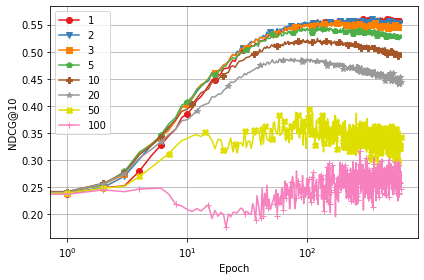

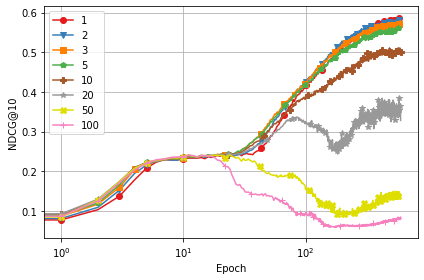

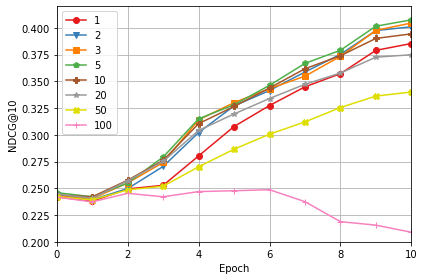

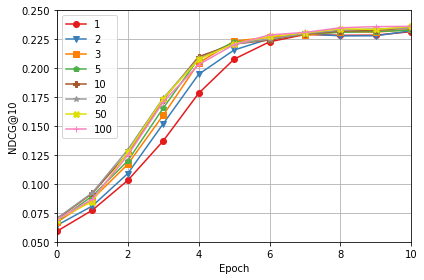

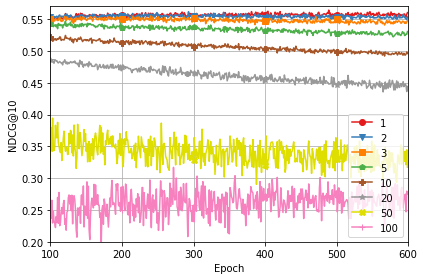

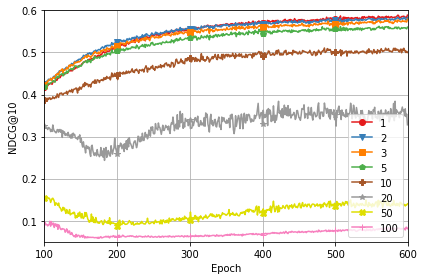

In [117]:
plot_name = "epochs_"+super_plot_name+"_GRU_SAS_"+subset_selection["data_params.name"]

#plot_instructions["subplots"] = {"nrows": 3, "ncols": 2, "figsize": (12,12)}
plot_instructions["savefig"] = {"fname": f'../out/img/{plot_name}.pdf'}

plot_kwargs = {"markevery": 0.1}

ax_instructions.pop("set_xticks",None)
ax_instructions["legend"] = {"loc": "upper left"}
#ax_instructions["set_title"] = {"label": super_title}

label_convert_dict = {} #x:f"{x} positive item(s)" for x in [1,2,3,5,10,20,50,100]}

repeated_ax_instructions = [ax_instructions.copy() for _ in range(6)]
repeated_ax_instructions[2]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[2]["set_ylim"] = {"bottom":0.2,"top":0.42}
repeated_ax_instructions[2].pop("set_xscale",None)
repeated_ax_instructions[3]["set_xlim"] = {"left":0,"right":10}
repeated_ax_instructions[3]["set_ylim"] = {"bottom":0.05,"top":0.25}
repeated_ax_instructions[3].pop("set_xscale",None)


repeated_ax_instructions[4]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[4]["set_ylim"] = {"bottom":0.2,"top":0.57}
repeated_ax_instructions[4].pop("set_xscale",None)
repeated_ax_instructions[4]["legend"] = {"loc":"lower right"}
repeated_ax_instructions[5]["set_xlim"] = {"left":100,"right":600}
repeated_ax_instructions[5]["set_ylim"] = {"bottom":0.05,"top":0.6}
repeated_ax_instructions[5].pop("set_xscale",None)
repeated_ax_instructions[5]["legend"] = {"loc":"lower right"}


repeated_plot_kwargs = [plot_kwargs.copy() for _ in range(6)]
repeated_plot_kwargs[2]["markevery"] = repeated_plot_kwargs[3]["markevery"] = 1
repeated_plot_kwargs[4]["markevery"] = repeated_plot_kwargs[5]["markevery"] = 100

label_a = ["(a)","(b)","(c)","(d)","(e)","(f)"]
label_b = ["GRU","SAS"]*3
label_c = [" - "+x if x !="" else x for x in ["","","start","start","end","end"]]
for i,(rep_ax_instr, rep_plot_kwargs) in enumerate(zip(repeated_ax_instructions,repeated_plot_kwargs)):
    rep_plot_instr = deepcopy(plot_instructions.copy())
    rep_plot_instr["savefig"]["fname"] = plot_instructions["savefig"]["fname"].split(".pdf")[0]+"_"+str(i)+".pdf"
    #rep_ax_instr["set_title"] = {"label": f"{label_a[i]} {label_b[i]}{label_c[i]}"}
    create_plot(rep_plot_instr, data=([gru_table,sas_table]*3)[i], label_columns=[main_x_column], x_column=x_column, y_column=y_column,
            ax_instructions = rep_ax_instr, label_convert_dict = label_convert_dict, plot_type="plot", plot_kwargs=rep_plot_kwargs)